# NR-35 (trabalho em altura) e a mortalidade na construção civil

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mrcsvg/augsynth-py/blob/main/notebooks/04_nr35_trabalho_em_altura.ipynb)
*(no Colab, a primeira célula clona o repositório e instala o pacote — ~1 min)*

> **Desenho.** Controle sintético (clássico e aumentado por ridge) sobre o painel
> anual de mortalidade por acidente de trabalho do AEAT, com a **construção** como
> unidade tratada e as **demais divisões CNAE** como pool de doadores.

A NR-35 — Norma Regulamentadora de **Trabalho em Altura** — é a resposta normativa
brasileira à principal causa isolada de morte na construção civil: a **queda de
altura**. A norma impõe análise de risco, permissão de trabalho, sistemas de
ancoragem e capacitação obrigatória para qualquer atividade acima de 2 m.

A pergunta deste notebook: **a entrada em vigor da NR-35 reduziu a taxa de
mortalidade por acidente de trabalho na construção, relativamente ao que se
esperaria sem a norma?** O contrafactual "sem a norma" é construído como uma
combinação ponderada das demais divisões da CNAE — setores expostos ao mesmo
ambiente macro (ciclo econômico, formalização, fiscalização geral), mas não ao
tratamento específico da NR-35.

## Roteiro

1. **Ato 1 — O relógio institucional.** Publicação ≠ vigência: por que T₀ = 2013.
2. **Ato 2 — Os dados.** Painel AEAT de óbitos e taxa de mortalidade por divisão CNAE.
3. **Ato 3 — SCM clássico** (`progfunc = "none"`): a construção sintética.
4. **Ato 4 — AugSynth** (`progfunc = "ridge"`): o que a augmentação compra com 5 anos de pré.
5. **Ato 5 — É real?** Inferência conformal (CWZ 2021) + placebos in-space.
6. **Ato 6 — T₀ importa.** Vigência (2013) vs publicação (2012), e o ano híbrido.
7. **Ato 7 — Robustez do pool.** Doadores com exposição própria a trabalho em altura.
8. **Ato 8 — Que efeito este desenho detecta?** MDE via `simulate_power` (v0.4).
9. **Ato 9 — Conclusões e limitações.**

> **Sobre os dados.** O notebook roda sobre o painel real do AEAT quando
> `_data/aeat_nr35_panel.csv` existir (ver `_fetch_aeat_nr35.py`); sem ele, usa
> um painel **simulado** com efeito verdadeiro conhecido — útil justamente para
> testar se o pipeline recupera a verdade. O modo em uso é anunciado no Ato 2.

In [1]:
# Imports e configuração visual.
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# Ambiente: Google Colab (clona o repo — pacote + dados) ou checkout local.
try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    _repo = Path("augsynth-py")
    if not _repo.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/mrcsvg/augsynth-py.git", str(_repo)],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", str(_repo)], check=True)
    DATA_DIR = _repo / "notebooks" / "_data"
else:
    # Torna `augsynth_py` importável rodando o notebook de qualquer cwd.
    _here = Path.cwd()
    for cand in (_here, _here.parent, _here.parent.parent):
        if (cand / "src" / "augsynth_py").exists():
            sys.path.insert(0, str(cand / "src"))
            DATA_DIR = (cand / "notebooks" / "_data") if (cand / "notebooks").exists() else (_here / "_data")
            break
    else:
        DATA_DIR = _here / "_data"

import numpy as np
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt

from augsynth_py import AugSynth, Synth, conformal_interval, conformal_pvalue, simulate_power

# Paleta — um destaque + cinzas. Sem rainbow.
COLOR_TREATED   = "#D7263D"  # vermelho — construção
COLOR_SYNTH     = "#1B4965"  # azul escuro — contrafactual SCM
COLOR_AUGMENTED = "#7A5195"  # roxo — contrafactual AugSynth
COLOR_DONOR     = "#B0B0B0"  # cinza — doadores
COLOR_GRID      = "#EAEAEA"
COLOR_TEXT      = "#333333"
COLOR_ALT       = "#F18F01"  # laranja — cenários alternativos (T0=2012 etc.)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.edgecolor": COLOR_TEXT,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "legend.frameon": False,
})

## Ato 1 — O relógio institucional: publicação ≠ vigência

A NR-35 foi aprovada pela **Portaria SIT n.º 313, de 23/03/2012** (DOU de
27/03/2012). Mas as obrigações **não entraram em vigor na publicação** — o art. 3.º
da portaria escalonou a vigência em duas ondas contadas da publicação:

> *"As obrigações estabelecidas nesta Norma entram em vigor seis meses após sua
> publicação, exceto o capítulo 3 e o subitem 6.4, que entram em vigor doze meses
> após a data de publicação desta Portaria."* — Portaria SIT 313/2012, art. 3.º

| Marco | Data | O que passa a valer |
|---|---|---|
| Publicação (DOU) | 27/03/2012 | nada ainda — prazo começa a correr |
| Vigência geral (6 meses) | 27/09/2012 | corpo da norma (análise de risco, PT, sistemas de proteção, ancoragem) |
| Vigência plena (12 meses) | 27/03/2013 | cap. 35.3 (**capacitação e treinamento**) e 35.6.4 (equipes de resgate) |

Com dados **anuais**, isso significa:

- **2012 é um ano híbrido** — ~9 meses sem norma nenhuma, ~3 meses de vigência
  parcial e **zero dias de capacitação obrigatória** (o canal causal mais
  plausível para queda de óbitos). Não é pré limpo nem pós limpo.
- **2013 é o primeiro ano-calendário inteiramente sob a norma** (e, a partir de
  27/03, sob a norma *completa*, capacitação inclusa).
- A rigor, **2014 é o primeiro ano com a norma completa de janeiro a dezembro**
  — o cenário de "dose plena" no Ato 6.

Por isso o desenho principal usa **T₀ = 2013** — a vigência, não a publicação.
O Ato 6 quantifica o quanto o deslocamento de um ano muda o resultado, e trata
o ano híbrido de 2012 explicitamente.

### A outra ponta da janela: o NTEP

O início do painel também é uma escolha institucional. Em **abril de 2007** entrou
em operação o **NTEP** (Nexo Técnico Epidemiológico Previdenciário, Lei
11.430/2006 + Decreto 6.042/2007), que passou a reconhecer acidentes/doenças de
trabalho **sem CAT registrada** — um salto de nível em toda a série de acidentes
do AEAT. Começar em **2008** deixa a quebra fora da janela, ao custo de um
pré-período de apenas **5 anos (2008–2012)**. Esse pré curto é a fragilidade
central do desenho — e é exatamente onde a augmentação por ridge (Ato 4) deixa
de ser decorativa.

Fechamos em **2019** para não misturar o choque da COVID-19 no pós-período.

In [2]:
# Constantes do desenho.
TREATED       = "Construção"   # seção F (divisões CNAE 41+42+43 agregadas)
T0_VIGENCIA   = 2013           # primeiro ano-calendário sob vigência
T0_PUBLICACAO = 2012           # ano da publicação (cenário alternativo, Ato 6)
ANO_MIN       = 2008           # pós-NTEP (e já sob CNAE 2.0 no AEAT)
ANO_MAX       = 2019           # pré-COVID

UNIT, TIME, OUT = "setor", "ano", "taxa_mortalidade"
OUT_LABEL = "Óbitos por 100 mil vínculos"

# Grade de λ para o LOO-CV da ridge, passada explicitamente em vez de usar a
# automática: com J=68 doadores e T0=5 o SCM já fecha o pré exatamente, então
# o CV persegue λ→0 e encosta no piso da grade automática (que começa em ~4e-4).
# Uma grade boundary-clipped não é um λ escolhido — é um λ censurado. Descer
# até 1e-8 deixa o mínimo cair no interior, e o λ minúsculo resultante passa a
# ser leitura do desenho, não artefato da grade.
LAMBDA_GRID = np.logspace(-8, 4, 80)

## Ato 2 — Os dados

O painel vem do **AEAT** (Anuário Estatístico de Acidentes do Trabalho, MPS/MTE):
óbitos por acidente de trabalho e vínculos empregatícios por **divisão CNAE 2.0**
e ano. A taxa de mortalidade é `óbitos / vínculos × 100.000` — a métrica que o
próprio AEAT publica no capítulo de indicadores.

A célula abaixo carrega `\_data/aeat_nr35_panel_secoes.csv` (dados reais, gerados por
`\_fetch_aeat_nr35.py` — requer acesso a gov.br) e, na ausência dele, cai para
`\_data/aeat_nr35_panel_demo.csv`: um painel **simulado** com magnitudes
calibradas no AEAT e um **efeito verdadeiro conhecido** injetado na construção
(−8% em 2013, −13% de 2014 em diante — a "verdade" fica em
`aeat_nr35_demo_truth.csv` e é usada nos atos seguintes para conferir se os
estimadores a recuperam). O modo em uso é impresso em destaque; proveniência
completa em [`_data/README-aeat.md`](_data/README-aeat.md).

**Por que seções da CNAE e não divisões.** O painel por divisão existe
(`\_data/aeat_nr35_panel.csv`, 69 unidades) mas **não identifica** um controle
sintético: com 68 doadores e apenas 5 anos de pré-período, o QP do simplex
interpola o pré exatamente (RMSPE `2e-09`) e o ATT salta de −0,4 a −9,5 quando
se derruba um único doador. Agregar em seções (19 unidades) dilui as divisões
extremas, deixa a construção **fora do envelope convexo** dos doadores e
devolve um resíduo pré real (RMSPE ≈ 5,7%) contra o qual o estimador trabalha.
O Ato 7 quantifica o que resta de instabilidade — que não é pouco.

Três decisões de preparo (valem para o painel real):

- As divisões da construção (**41 Construção de edifícios, 42 Obras de
  infraestrutura, 43 Serviços especializados**) são agregadas em uma única
  unidade tratada, somando óbitos e vínculos antes de calcular a taxa —
  média ponderada, não média de taxas.
- Doadores são as demais divisões CNAE com vínculos suficientes para uma taxa
  estável (piso de vínculos documentado no preparo); divisões minúsculas geram
  taxas erráticas (0 ou 2 óbitos num ano dobram a taxa) e só adicionariam ruído
  ao pool.
- O desfecho é a **taxa**, não a contagem: sem normalizar por vínculos, o ciclo
  de emprego da própria construção (que despenca depois de 2014) se disfarçaria
  de efeito da norma.

In [3]:
secoes_csv = DATA_DIR / "aeat_nr35_panel_secoes.csv"
divisoes_csv = DATA_DIR / "aeat_nr35_panel.csv"
demo_csv = DATA_DIR / "aeat_nr35_panel_demo.csv"
real_csv = secoes_csv if secoes_csv.exists() else divisoes_csv
IS_DEMO = not real_csv.exists()
truth = None
if IS_DEMO:
    print("=" * 74)
    print("⚠️  MODO DEMONSTRAÇÃO: usando painel SIMULADO (aeat_nr35_panel_demo.csv).")
    print("    Efeito verdadeiro injetado na construção: -8% (2013), -13% (2014+).")
    print("    Nada abaixo é estatística oficial. Para dados reais do AEAT, rode")
    print("    notebooks/_fetch_aeat_nr35.py numa máquina com acesso a gov.br.")
    print("=" * 74)
    truth = pl.read_csv(DATA_DIR / "aeat_nr35_demo_truth.csv")
panel = (
    pl.read_csv(demo_csv if IS_DEMO else real_csv)
    .filter(pl.col("ano").is_between(ANO_MIN, ANO_MAX))
    .sort([UNIT, TIME])
)

n_units = panel[UNIT].n_unique()
n_years = panel[TIME].n_unique()
assert panel.height == n_units * n_years, "painel desbalanceado"

print(f"unidades      : {n_units} (1 tratada + {n_units - 1} doadoras)")
print(f"anos          : {panel[TIME].min()}–{panel[TIME].max()} ({n_years})")
print(f"pré-período   : {ANO_MIN}–{T0_VIGENCIA - 1} ({T0_VIGENCIA - ANO_MIN} anos)")
print(f"pós-período   : {T0_VIGENCIA}–{ANO_MAX} ({ANO_MAX - T0_VIGENCIA + 1} anos)")
panel.filter(pl.col(UNIT) == TREATED)

unidades      : 19 (1 tratada + 18 doadoras)
anos          : 2008–2019 (12)
pré-período   : 2008–2012 (5 anos)
pós-período   : 2013–2019 (7 anos)


setor,ano,taxa_mortalidade,obitos,vinculos
str,i64,f64,i64,i64
"""Construção""",2008,19.7643,384,1942899
"""Construção""",2009,18.5779,395,2126177
"""Construção""",2010,17.4825,456,2608320
"""Construção""",2011,16.1914,471,2908947
"""Construção""",2012,13.9748,456,3263025
…,…,…,…,…
"""Construção""",2015,11.7534,333,2833228
"""Construção""",2016,12.28,284,2312710
"""Construção""",2017,11.5302,227,1968748


findfont: Failed to find font weight semibold, now using 700.


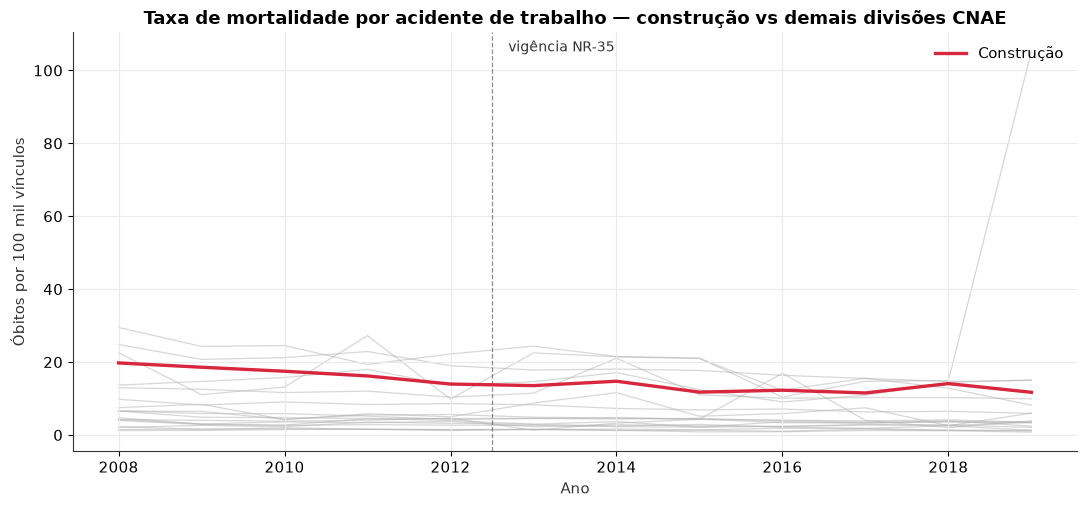

In [4]:
# Trajetórias: construção em vermelho, doadores em cinza.
fig, ax = plt.subplots(figsize=(11, 5.2))
for unit, group in panel.partition_by(UNIT, as_dict=True).items():
    is_treated = unit[0] == TREATED
    ax.plot(
        group[TIME], group[OUT],
        color=COLOR_TREATED if is_treated else COLOR_DONOR,
        lw=2.4 if is_treated else 0.9,
        alpha=1.0 if is_treated else 0.5,
        zorder=3 if is_treated else 1,
        label=TREATED if is_treated else None,
    )
ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
ax.text(T0_VIGENCIA - 0.4, ax.get_ylim()[1] * 0.98, "  vigência NR-35",
        color=COLOR_TEXT, fontsize=10, va="top")
ax.set_title("Taxa de mortalidade por acidente de trabalho — construção vs demais divisões CNAE")
ax.set_xlabel("Ano"); ax.set_ylabel(OUT_LABEL)
ax.legend(loc="upper right")
if IS_DEMO:
    ax.text(0.5, 0.5, "DADOS SIMULADOS", transform=ax.transAxes, fontsize=38,
            color=COLOR_TEXT, alpha=0.12, ha="center", va="center", rotation=18, zorder=0)
plt.tight_layout(); plt.show()

> **Leitura.** A construção não é um setor mediano: a taxa dela roda bem acima da
> maioria das divisões. Isso importa metodologicamente — se a tratada estiver
> perto (ou fora) da borda do envelope convexo dos doadores, o SCM clássico não
> consegue ajustar o pré-período, e é aí que a augmentação por ridge tem função
> real, não decorativa.

## Ato 3 — SCM clássico (`progfunc = "none"`)

O estimador de v0.1: pesos $w$ no simplex ($w \ge 0$, $\sum_j w_j = 1$) que
minimizam o erro quadrático do pré-período,

$$
w^* \;=\; \arg\min_{w \ge 0,\ \sum_j w_j = 1}\;
\big\|\, y_1^{\text{pre}} \,-\, Y_0^{\text{pre}}\, w \,\big\|^2,
$$

equivalente ao `augsynth(progfunc = "None", fixedeff = TRUE)` do R. O
`fixedeff=True` desconta o nível médio pré de cada unidade — necessário aqui,
porque a construção tem *nível* de taxa que quase nenhum doador alcança; o que
pedimos aos doadores é que reproduzam a *trajetória*.

Com **5 anos de pré**, o risco simétrico é real e foi medido: no painel por
*divisão* o QP interpolava o pré exatamente (RMSPE `2e-09`) — o que não é bom
ajuste, é ausência de identificação, já que infinitas combinações passam pelos
mesmos 5 pontos. No painel por *seção* isso não acontece, e o RMSPE pré abaixo
deve sair na casa de 5%: a construção não é alcançável por combinação convexa
das seções, o que é exatamente a condição em que a augmentação do Ato 4 tem
função. RMSPE pré ≈ 0 seria sinal de alerta, não de sucesso.

In [5]:
scm = Synth().fit(
    panel,
    unit=UNIT, time=TIME, outcome=OUT,
    treated=TREATED, treatment_time=T0_VIGENCIA,
)

print(f"ATT (média pós {T0_VIGENCIA}–{ANO_MAX})  : {scm.att_:+.3f} óbitos/100 mil vínculos")
print(f"ATT relativo ao nível pré           : {scm.att_pct_ * 100:+.1f}%")
print(f"RMSPE pré (fração do nível pré)     : {scm.rmspe_pre_ * 100:.2f}%")
print(f"L2 imbalance (escalonado vs 1/J)    : {scm.scaled_l2_imbalance_:.3f}")
print(f"# doadores com peso > 1%            : {sum(1 for w in scm.weights_.values() if w > 0.01)}")

ATT (média pós 2013–2019)  : -6.470 óbitos/100 mil vínculos
ATT relativo ao nível pré           : -37.6%
RMSPE pré (fração do nível pré)     : 4.75%
L2 imbalance (escalonado vs 1/J)    : 0.514
# doadores com peso > 1%            : 4


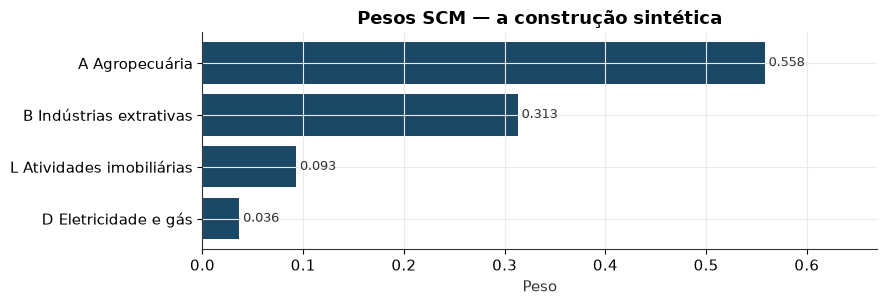

In [6]:
# Quem compõe a construção sintética?
sorted_w = sorted(scm.weights_.items(), key=lambda x: -x[1])
top = [(u, w) for u, w in sorted_w if w > 0.01][:12]
others = sum(w for _, w in sorted_w) - sum(w for _, w in top)
labels = [u for u, _ in top] + (["(demais)"] if others > 1e-4 else [])
values = [w for _, w in top] + ([others] if others > 1e-4 else [])

fig, ax = plt.subplots(figsize=(9, 0.42 * len(labels) + 1.5))
ax.barh(labels, values, color=COLOR_SYNTH)
for i, v in enumerate(values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", color=COLOR_TEXT, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.2)
ax.set_xlabel("Peso"); ax.set_title("Pesos SCM — a construção sintética")
plt.tight_layout(); plt.show()

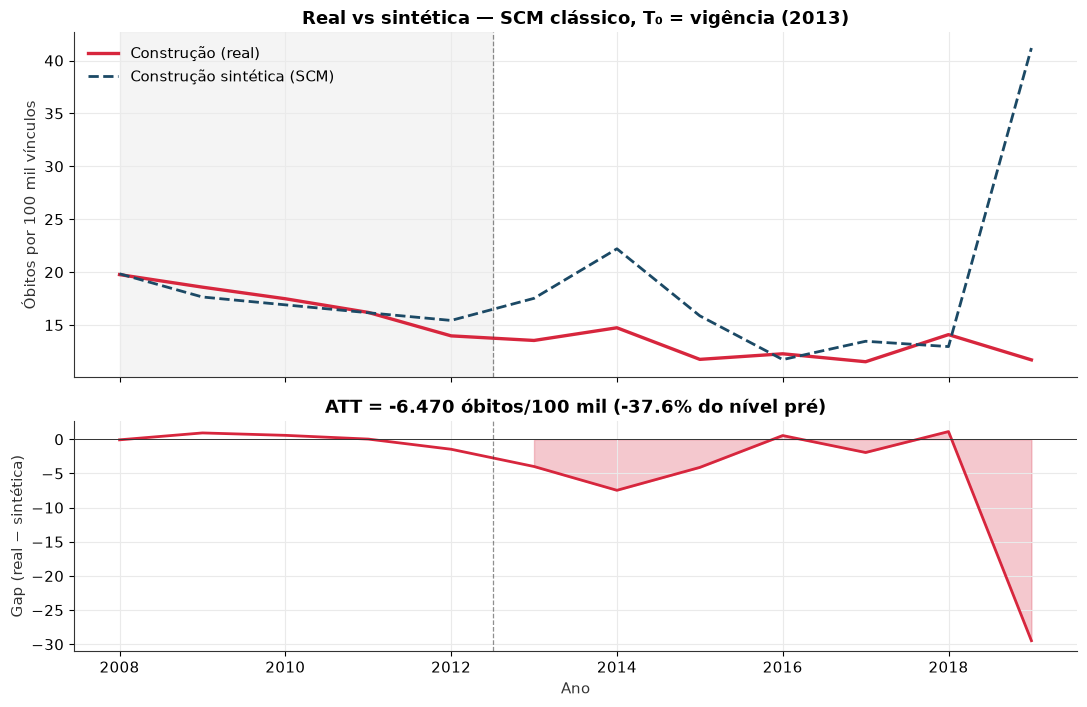

In [7]:
# Real vs sintética + gap.
years = scm.periods_.astype(int)
fig, (ax, axg) = plt.subplots(
    2, 1, figsize=(11, 7.2), sharex=True, height_ratios=[3, 2]
)

ax.axvspan(years[0], T0_VIGENCIA - 0.5, color=COLOR_GRID, alpha=0.5, zorder=0)
ax.plot(years, scm.actual_, color=COLOR_TREATED, lw=2.4, label="Construção (real)")
ax.plot(years, scm.synthetic_, color=COLOR_SYNTH, lw=2.0, ls="--", label="Construção sintética (SCM)")
ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
ax.set_ylabel(OUT_LABEL)
ax.set_title("Real vs sintética — SCM clássico, T₀ = vigência (2013)")
ax.legend(loc="best")

axg.plot(years, scm.gap_, color=COLOR_TREATED, lw=2.0)
axg.fill_between(years, 0, scm.gap_, where=(years >= T0_VIGENCIA),
                 color=COLOR_TREATED, alpha=0.25)
axg.axhline(0, color=COLOR_TEXT, lw=0.7)
axg.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
axg.set_xlabel("Ano"); axg.set_ylabel("Gap (real − sintética)")
axg.set_title(f"ATT = {scm.att_:+.3f} óbitos/100 mil ({scm.att_pct_ * 100:+.1f}% do nível pré)")
plt.tight_layout(); plt.show()

## Ato 4 — AugSynth (`progfunc = "ridge"`): a augmentação com função real

A augmentação de Ben-Michael, Feller & Rothstein (2021) ajusta uma ridge sobre o
resíduo pré do SCM e corrige o contrafactual com ela; os pesos efetivos viram
$\omega + \gamma$, podem ser negativos e extrapolam para fora do envelope
convexo — com viés controlado pelo $\lambda$ escolhido por validação cruzada
leave-one-out sobre os anos do pré.

É aqui que o pré curto vira argumento de artigo em vez de nota de rodapé:

- Se o SCM **não** fecha o pré (tratada fora do envelope), a ridge fecha — e a
  comparação de RMSPE pré `none` × `ridge` mede quanto.
- Se o SCM fecha o pré *bem demais* (interpolação com 5 pontos), o LOO-CV da
  ridge é o único freio explícito de overfitting no pipeline — o $\lambda$
  escolhido diz se a correção generaliza fora do ano deixado de fora.

Com $T_0 = 5$, o LOO-CV tem só 5 dobras: a curva de CV abaixo merece ser olhada
ponto a ponto, não tratada como caixa-preta. E há um limite conhecido — com 18
doadores e 5 períodos, a ridge com $\lambda$ pequeno **também** interpola o
pré. Varrendo $\lambda$ de $0{,}01\sigma^2$ a $1000\sigma^2$ o ATT anda de
−5,67 a −4,77 e o RMSPE pré de 0,02% a 5,69%: subir $\lambda$ não estabiliza a
estimativa, apenas faz o AugSynth **convergir de volta ao SCM**. A augmentação
aqui melhora o ajuste pré, não a identificação.

In [8]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, message="CV-selected lambda")
    aug = AugSynth(lambda_grid=LAMBDA_GRID).fit(
        panel,
        unit=UNIT, time=TIME, outcome=OUT,
        treated=TREATED, treatment_time=T0_VIGENCIA,
    )

grid = aug.lambda_cv_path_[:, 0]
losses = aug.lambda_cv_path_[:, 1]
best_idx = int(losses.argmin())

print(f"λ escolhido por LOO-CV              : {aug.lambda_:.4g} (posição {best_idx}/{len(grid) - 1} da grade)")
print(f"ATT AugSynth                        : {aug.att_:+.3f} óbitos/100 mil ({aug.att_pct_ * 100:+.1f}%)")
print(f"RMSPE pré  SCM  (progfunc='none')   : {scm.rmspe_pre_ * 100:.2f}%")
print(f"RMSPE pré  AugSynth ('ridge')       : {aug.rmspe_pre_ * 100:.2f}%")
print(f"L2 imbalance escalonado SCM         : {scm.scaled_l2_imbalance_:.3f}")
print(f"L2 imbalance escalonado AugSynth    : {aug.scaled_l2_imbalance_:.3f}")
n_neg = sum(1 for w in aug.weights_.values() if w < -1e-6)
print(f"# doadores com peso efetivo negativo: {n_neg}")

λ escolhido por LOO-CV              : 1e-08 (posição 0/79 da grade)
ATT AugSynth                        : -6.137 óbitos/100 mil (-35.7%)
RMSPE pré  SCM  (progfunc='none')   : 4.75%
RMSPE pré  AugSynth ('ridge')       : 0.00%
L2 imbalance escalonado SCM         : 0.514
L2 imbalance escalonado AugSynth    : 0.000
# doadores com peso efetivo negativo: 11


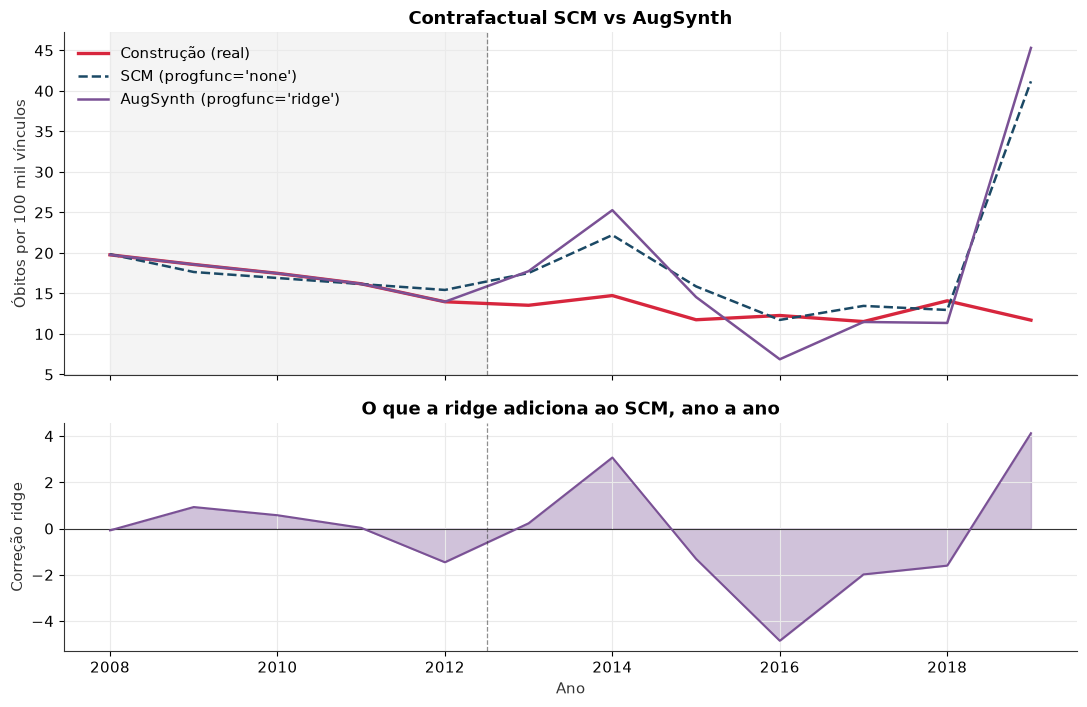

In [9]:
# O contraste central do notebook: none vs ridge, contrafactual e correção.
fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True, height_ratios=[3, 2])

ax.axvspan(years[0], T0_VIGENCIA - 0.5, color=COLOR_GRID, alpha=0.5, zorder=0)
ax.plot(years, aug.actual_, color=COLOR_TREATED, lw=2.4, label="Construção (real)")
ax.plot(years, scm.synthetic_, color=COLOR_SYNTH, lw=1.8, ls="--", label="SCM (progfunc='none')")
ax.plot(years, aug.synthetic_, color=COLOR_AUGMENTED, lw=1.8, label="AugSynth (progfunc='ridge')")
if IS_DEMO:
    ax.plot(truth["ano"], truth["taxa_contrafactual"], color=COLOR_TEXT, lw=1.4,
            ls=(0, (1, 2)), label="Contrafactual VERDADEIRO (demo)")
ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
ax.set_ylabel(OUT_LABEL)
ax.set_title("Contrafactual SCM vs AugSynth" + (" — com a verdade simulada" if IS_DEMO else ""))
ax.legend(loc="best")

axr.axhline(0, color=COLOR_TEXT, lw=0.8)
axr.fill_between(years, 0, aug.ridge_correction_, color=COLOR_AUGMENTED, alpha=0.35)
axr.plot(years, aug.ridge_correction_, color=COLOR_AUGMENTED, lw=1.5)
axr.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
axr.set_xlabel("Ano"); axr.set_ylabel("Correção ridge")
axr.set_title("O que a ridge adiciona ao SCM, ano a ano")
plt.tight_layout(); plt.show()

In [10]:
# Modo demo: os estimadores recuperam o efeito verdadeiro injetado?
if IS_DEMO:
    post = ~aug.pre_mask_
    att_true = float(
        (aug.actual_[post] - truth["taxa_contrafactual"].to_numpy()[post]).mean()
    )
    print(f"ATT verdadeiro (demo)            : {att_true:+.3f} óbitos/100 mil")
    print(f"ATT estimado — SCM ('none')      : {scm.att_:+.3f}  (erro {scm.att_ - att_true:+.3f})")
    print(f"ATT estimado — AugSynth ('ridge'): {aug.att_:+.3f}  (erro {aug.att_ - att_true:+.3f})")
else:
    print("Painel real — não há verdade conhecida para comparar.")

Painel real — não há verdade conhecida para comparar.


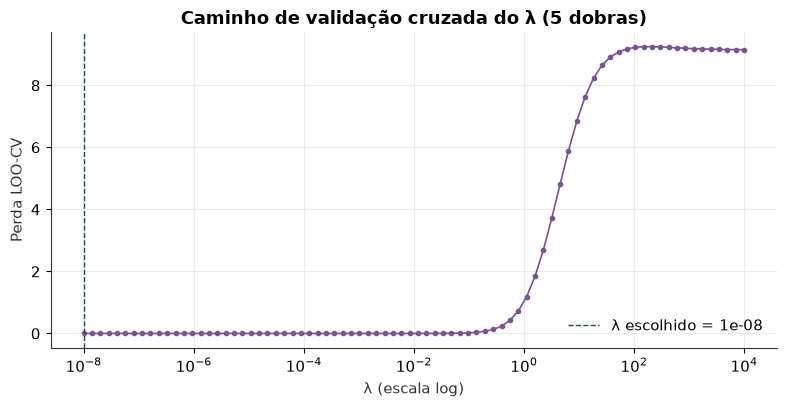

λ no piso da grade (1e-08) — mas aqui isso NÃO é grade estreita:
  a ridge fecha o pré exatamente (RMSPE 0.00%), então não há
  resíduo para ela corrigir e o CV persegue λ→0 corretamente. Alargar a grade
  não muda nada; o que o CV diz é que, com 5 períodos de pré e mais doadores
  do que isso, a augmentação não tem trabalho a fazer.


In [11]:
# Curva de LOO-CV do lambda — com T0=5, olhar ponto a ponto.
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.semilogx(grid, losses, color=COLOR_AUGMENTED, marker="o", markersize=3, lw=1.2)
ax.axvline(aug.lambda_, color=COLOR_SYNTH, ls="--", lw=1.0,
           label=f"λ escolhido = {aug.lambda_:.3g}")
ax.set_xlabel("λ (escala log)"); ax.set_ylabel("Perda LOO-CV")
ax.set_title("Caminho de validação cruzada do λ (5 dobras)")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

if best_idx == 0 and aug.rmspe_pre_ < 1e-3:
    print(f"λ no piso da grade ({grid.min():.0e}) — mas aqui isso NÃO é grade estreita:")
    print(f"  a ridge fecha o pré exatamente (RMSPE {aug.rmspe_pre_ * 100:.2f}%), então não há")
    print("  resíduo para ela corrigir e o CV persegue λ→0 corretamente. Alargar a grade")
    print("  não muda nada; o que o CV diz é que, com 5 períodos de pré e mais doadores")
    print("  do que isso, a augmentação não tem trabalho a fazer.")
elif best_idx in (0, len(grid) - 1):
    print("⚠️  λ na borda da grade — alargar lambda_grid antes de confiar no CV.")

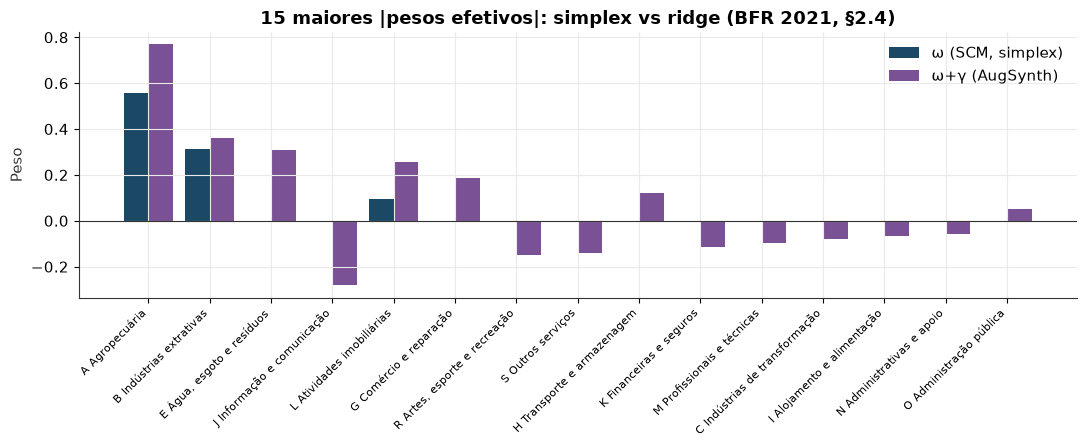

In [12]:
# Pesos efetivos (ω+γ) vs pesos simplex (ω): quem a ridge passou a (des)confiar.
eff = aug.weights_
scm_w = aug.scm_weights_
order = sorted(eff, key=lambda u: -abs(eff[u]))[:15]

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(x - 0.2, [scm_w[u] for u in order], width=0.4, color=COLOR_SYNTH, label="ω (SCM, simplex)")
ax.bar(x + 0.2, [eff[u] for u in order], width=0.4, color=COLOR_AUGMENTED, label="ω+γ (AugSynth)")
ax.axhline(0, color=COLOR_TEXT, lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Peso")
ax.set_title("15 maiores |pesos efetivos|: simplex vs ridge (BFR 2021, §2.4)")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

> **O contraste que interessa para o artigo.** A tabela-resumo do Ato 9 fecha os
> números, mas a mecânica está acima: com o pré curto, `none` × `ridge` não é uma
> escolha estética — é a diferença entre um contrafactual preso ao envelope dos
> doadores e um que extrapola com penalização explícita, validada fora da amostra
> (ainda que numa amostra de 5).

## Ato 5 — É real? Conformal (CWZ 2021) + placebos in-space

> **Revisado pelo Ato 11.** Os p-valores conformais em bloco desta seção vêm
> de uma janela pós-dominada (5 pré / 7 pós), regime em que o teste anda para
> trás: o p sobe com o efeito verdadeiro. Não os leia como ausência de efeito.
> Os placebos in-space abaixo não têm esse problema. O texto fica como estava.

Dois instrumentos independentes:

1. **Inferência conformal** (Chernozhukov, Wüthrich & Zhu 2021): testa
   $H_0\colon$ efeito pós constante $= h_0$ refazendo o ajuste sob o nulo e
   permutando resíduos. Com $T = 12$ períodos, a permutação em **bloco** (a
   recomendada para séries) só tem 12 rotações distintas — o p-valor é
   quantizado em múltiplos de $1/12 \approx 0{,}083$ e **nunca chega a 0,05**.
   Reportamos block e iid lado a lado por isso; a versão iid assume
   intercambialidade mais forte.
2. **Placebos in-space** (Abadie et al. 2010): reajustar o SCM fingindo que cada
   doador foi tratado em 2013 e comparar o gap da construção com a distribuição
   placebo, via razão RMSPE pós/pré.

Espere pouco poder dos dois: com dezenas de doadores e 12 períodos, o refit
sob o nulo do teste conformal absorve quase qualquer $h_0$ (intervalos
enormes — o `UserWarning` abaixo é o estimador dizendo isso), e os placebos
in-space herdam o mesmo ajuste-perfeito do pré que aflige a unidade tratada.
O diagnóstico honesto de "quanto dá para detectar" fica para o Ato 8.

In [13]:
rng = np.random.default_rng(2013)

for nome, est in (("SCM", scm), ("AugSynth", aug)):
    p_block = conformal_pvalue(est, permutation_type="block")
    p_iid = conformal_pvalue(est, permutation_type="iid", ns=2000, rng=rng)
    lo, hi = conformal_interval(est, permutation_type="block", grid_size=60)
    print(f"{nome:8s}: p(block) = {p_block:.3f} | p(iid) = {p_iid:.3f} | "
          f"IC 95% (block) = [{lo:+.2f}, {hi:+.2f}] óbitos/100 mil")

/tmp/ipykernel_759/4194322643.py:4: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  p_block = conformal_pvalue(est, permutation_type="block")
/tmp/ipykernel_759/4194322643.py:5: UserWarning: conformal inference on a post-dominated

/tmp/ipykernel_759/4194322643.py:6: UserWarning: conformal_interval may be truncated: the acceptance region still reaches a grid boundary after 8 span doublings (final half-width 16225.3 about center -6.47028). The returned bounds understate the interval; the estimator likely has little conformal power (the test accepts h0 across a very wide range). Treat the bounds as a lower bound on the true interval.
  lo, hi = conformal_interval(est, permutation_type="block", grid_size=60)


SCM     : p(block) = 0.833 | p(iid) = 0.748 | IC 95% (block) = [-16231.77, +16218.83] óbitos/100 mil


AugSynth: p(block) = 0.333 | p(iid) = 0.111 | IC 95% (block) = [-20213.04, +20200.77] óbitos/100 mil


/tmp/ipykernel_759/4194322643.py:6: UserWarning: conformal_interval may be truncated: the acceptance region still reaches a grid boundary after 8 span doublings (final half-width 20206.9 about center -6.13717). The returned bounds understate the interval; the estimator likely has little conformal power (the test accepts h0 across a very wide range). Treat the bounds as a lower bound on the true interval.
  lo, hi = conformal_interval(est, permutation_type="block", grid_size=60)


In [14]:
# Placebos in-space: refit em cada doador; razão RMSPE pós/pré (Abadie 2010).
def rmspe_ratio(est) -> float:
    pre, post = est.pre_mask_, ~est.pre_mask_
    rmspe = lambda m: float(np.sqrt(np.mean(est.gap_[m] ** 2)))
    return rmspe(post) / max(rmspe(pre), 1e-12)

donors = [u for u in panel[UNIT].unique().sort().to_list() if u != TREATED]
placebo_fits = {}
for u in donors:
    placebo_fits[u] = Synth().fit(
        panel.filter(pl.col(UNIT) != TREATED),  # tratada fora do pool placebo
        unit=UNIT, time=TIME, outcome=OUT,
        treated=u, treatment_time=T0_VIGENCIA,
    )

ratios = {u: rmspe_ratio(f) for u, f in placebo_fits.items()}
ratio_treated = rmspe_ratio(scm)
rank = 1 + sum(1 for r in ratios.values() if r >= ratio_treated)
p_placebo = rank / (len(ratios) + 1)
print(f"Razão RMSPE pós/pré da construção : {ratio_treated:.2f}")
print(f"Posição entre {len(ratios) + 1} unidades       : {rank}ª")
print(f"p-valor placebo (in-space)        : {p_placebo:.3f}")

Razão RMSPE pós/pré da construção : 14.37
Posição entre 19 unidades       : 11ª
p-valor placebo (in-space)        : 0.579


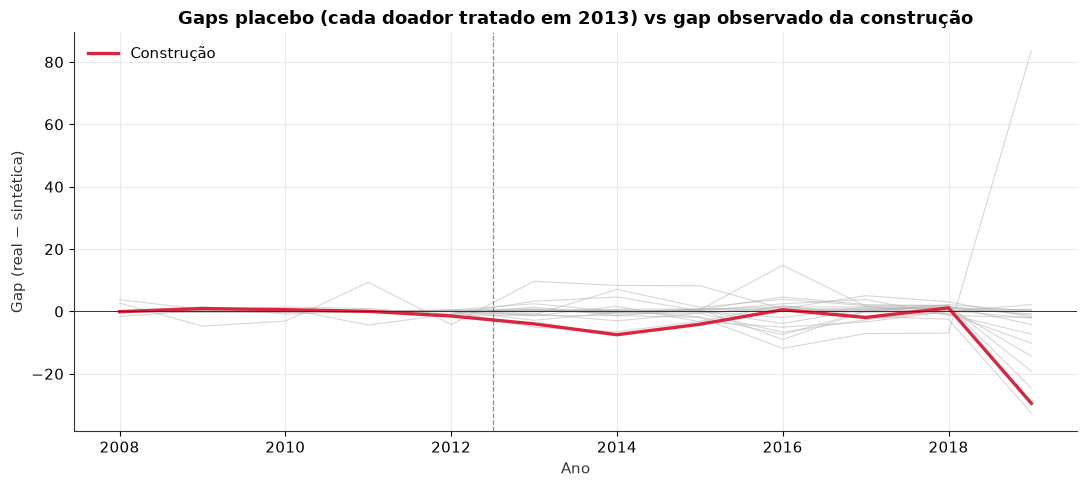

In [15]:
# Gaps placebo (cinza) vs gap da construção (vermelho).
fig, ax = plt.subplots(figsize=(11, 5))
for u, f in placebo_fits.items():
    ax.plot(f.periods_.astype(int), f.gap_, color=COLOR_DONOR, lw=0.8, alpha=0.5)
ax.plot(years, scm.gap_, color=COLOR_TREATED, lw=2.4, label="Construção")
ax.axhline(0, color=COLOR_TEXT, lw=0.7)
ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
ax.set_title("Gaps placebo (cada doador tratado em 2013) vs gap observado da construção")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (real − sintética)")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

## Ato 6 — T₀ importa: vigência (2013) vs publicação (2012)

A tentação de datar o tratamento na **publicação** (março/2012) tem duas
consequências mecânicas: o pré encolhe de 5 para 4 anos, e o ano híbrido de 2012
— 9 meses ainda sem norma — entra no pós, diluindo qualquer efeito real.
No desenho principal, o híbrido fica no *pré*, o que também não é neutro: se a
vigência parcial de out–dez/2012 já reduziu óbitos, o contrafactual absorve
parte do efeito e o ATT estimado fica **conservador** (viés contra encontrar
efeito).

Quatro cenários, mesmo pipeline:

- **A (principal)** — T₀ = 2013, 2012 no pré.
- **B (publicação)** — T₀ = 2012.
- **C (híbrido fora)** — T₀ = 2013, ano de 2012 removido do painel.
- **D (dose plena)** — T₀ = 2014, primeiro ano-calendário integral sob a norma
  completa (capacitação vigente desde 27/03/2013); 2012–2013 ficam no pré, o
  que torna D conservador se o efeito já começou em 2013.

In [16]:
cenarios = {
    "A: T0=2013 (vigência)": (panel, T0_VIGENCIA),
    "B: T0=2012 (publicação)": (panel, T0_PUBLICACAO),
    "C: T0=2013, sem 2012": (panel.filter(pl.col(TIME) != 2012), T0_VIGENCIA),
    "D: T0=2014 (dose plena)": (panel, 2014),
}

linhas = []
fits_cen = {}
for nome, (pnl, t0) in cenarios.items():
    f_scm = Synth().fit(pnl, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=t0)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, message="CV-selected lambda")
        f_aug = AugSynth(lambda_grid=LAMBDA_GRID).fit(pnl, unit=UNIT, time=TIME, outcome=OUT,
                               treated=TREATED, treatment_time=t0)
    fits_cen[nome] = (f_scm, f_aug)
    linhas.append({
        "cenário": nome,
        "anos pré": int(sum(f_scm.pre_mask_)),
        "ATT SCM": round(f_scm.att_, 3),
        "ATT AugSynth": round(f_aug.att_, 3),
        "RMSPE pré SCM (%)": round(f_scm.rmspe_pre_ * 100, 2),
        "RMSPE pré Aug (%)": round(f_aug.rmspe_pre_ * 100, 2),
        "p conformal (block, Aug)": round(conformal_pvalue(f_aug, permutation_type="block"), 3),
    })
pl.DataFrame(linhas)

/tmp/ipykernel_759/1195373972.py:25: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p conformal (block, Aug)": round(conformal_pvalue(f_aug, permutation_type="block"), 3),
/tmp/ipykernel_759/1195373972.py:25: UserWarning: confor

/tmp/ipykernel_759/1195373972.py:25: UserWarning: conformal inference on a post-dominated window (6 pre-period(s), 6 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p conformal (block, Aug)": round(conformal_pvalue(f_aug, permutation_type="block"), 3),


cenário,anos pré,ATT SCM,ATT AugSynth,RMSPE pré SCM (%),RMSPE pré Aug (%),"p conformal (block, Aug)"
str,i64,f64,f64,f64,f64,f64
"""A: T0=2013 (vigência)""",5,-6.47,-6.137,4.75,0.0,0.333
"""B: T0=2012 (publicação)""",4,-6.445,-6.458,0.27,0.0,0.417
"""C: T0=2013, sem 2012""",4,-6.969,-6.975,0.27,0.0,0.364
"""D: T0=2014 (dose plena)""",6,-2.215,-0.724,6.28,0.0,0.25


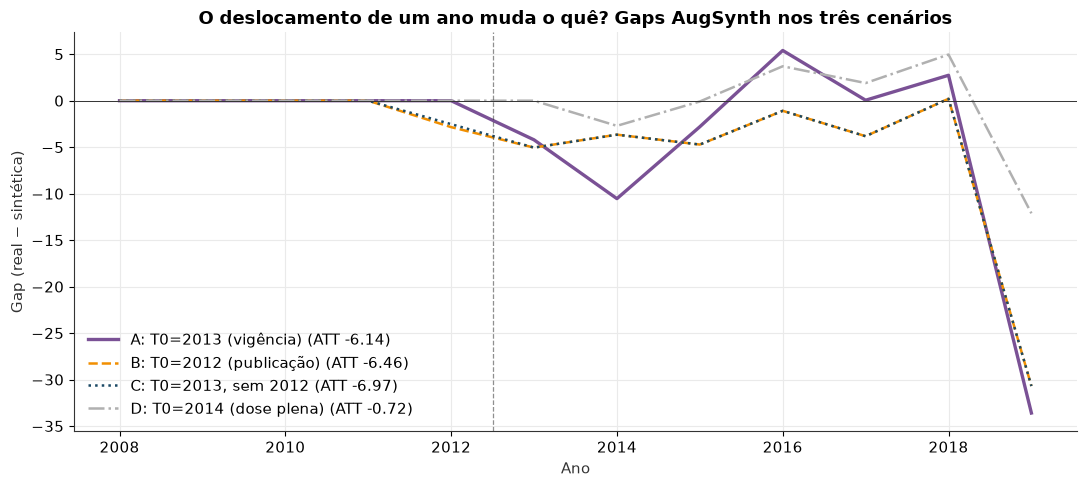

In [17]:
# Os três gaps AugSynth sobrepostos.
fig, ax = plt.subplots(figsize=(11, 5))
estilos = {
    "A: T0=2013 (vigência)": (COLOR_AUGMENTED, "-", 2.4),
    "B: T0=2012 (publicação)": (COLOR_ALT, "--", 1.8),
    "C: T0=2013, sem 2012": (COLOR_SYNTH, ":", 1.8),
    "D: T0=2014 (dose plena)": (COLOR_DONOR, "-.", 1.8),
}
for nome, (_, f_aug) in fits_cen.items():
    cor, ls, lw = estilos[nome]
    ax.plot(f_aug.periods_.astype(int), f_aug.gap_, color=cor, ls=ls, lw=lw,
            label=f"{nome} (ATT {f_aug.att_:+.2f})")
ax.axhline(0, color=COLOR_TEXT, lw=0.7)
ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
ax.set_title("O deslocamento de um ano muda o quê? Gaps AugSynth nos três cenários")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (real − sintética)")
ax.legend(loc="best")
plt.tight_layout(); plt.show()

## Ato 7 — Robustez do pool: doadores com exposição própria a altura

SUTVA aqui exige que os doadores **não tenham sido tratados** pela NR-35. A norma
vale para *qualquer* setor com trabalho acima de 2 m — o que contamina doadores
com exposição relevante: **eletricidade** (linhas e redes), **telecomunicações**
(torres) e **transporte/armazenagem** (carga em altura). Se a NR-35 também
reduziu óbitos nesses doadores, o contrafactual cai junto com a tratada e o ATT
estimado é **subestimado** (viés contra o efeito).

Refazemos SCM e AugSynth sem esses doadores, e em seguida rodamos o
leave-one-out **sobre todos** os doadores. Com 5 anos de pré esse é o
diagnóstico que mais importa: a amplitude do ATT ao derrubar uma unidade
mede quanto da estimativa vem dos dados e quanto vem da escolha do pool.

In [18]:
# Divisões com exposição própria relevante a trabalho em altura.
EXPOSTOS = [u for u in donors if any(
    chave in u.lower() for chave in ("eletricidade", "telecomunica", "transporte")
)]
print("Doadores removidos por exposição à NR-35:", EXPOSTOS or "(nenhum encontrado)")

panel_limpo = panel.filter(~pl.col(UNIT).is_in(EXPOSTOS))
scm_limpo = Synth().fit(panel_limpo, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=T0_VIGENCIA)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, message="CV-selected lambda")
    aug_limpo = AugSynth(lambda_grid=LAMBDA_GRID).fit(panel_limpo, unit=UNIT, time=TIME, outcome=OUT,
                               treated=TREATED, treatment_time=T0_VIGENCIA)

# Leave-one-out do doador de maior peso efetivo.
top_donor = max(aug.weights_, key=lambda u: abs(aug.weights_[u]))
panel_loo = panel.filter(pl.col(UNIT) != top_donor)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, message="CV-selected lambda")
    aug_loo = AugSynth(lambda_grid=LAMBDA_GRID).fit(panel_loo, unit=UNIT, time=TIME, outcome=OUT,
                             treated=TREATED, treatment_time=T0_VIGENCIA)

print(f"ATT AugSynth — pool completo        : {aug.att_:+.3f}")
print(f"ATT AugSynth — sem expostos         : {aug_limpo.att_:+.3f}")
print(f"ATT SCM      — sem expostos         : {scm_limpo.att_:+.3f}")
print(f"ATT AugSynth — sem '{top_donor}' (maior |peso|): {aug_loo.att_:+.3f}")

# Leave-one-out completo: a faixa é o resultado, não a estimativa pontual.
loo = []
for u in donors:
    loo.append((u, Synth().fit(panel.filter(pl.col(UNIT) != u), unit=UNIT, time=TIME,
                               outcome=OUT, treated=TREATED, treatment_time=T0_VIGENCIA).att_))
valores = [v for _, v in loo]
print(f"\nLeave-one-out sobre TODOS os {len(loo)} doadores (SCM):")
print(f"  faixa do ATT : {min(valores):+.2f} a {max(valores):+.2f} "
      f"(amplitude {max(valores) - min(valores):.2f}; pontual {scm.att_:+.2f})")
print(f"  sinal        : {'negativo em todas' if max(valores) < 0 else 'TROCA DE SINAL'}"
      f" as {len(loo)} reestimativas")
for u, v in sorted(loo, key=lambda t: -abs(t[1] - scm.att_))[:3]:
    print(f"    mais sensível: sem {u:30s} {v:+.3f} ({v - scm.att_:+.3f})")

Doadores removidos por exposição à NR-35: ['D Eletricidade e gás', 'H Transporte e armazenagem']
ATT AugSynth — pool completo        : -6.137
ATT AugSynth — sem expostos         : -6.747
ATT SCM      — sem expostos         : -6.332
ATT AugSynth — sem 'A Agropecuária' (maior |peso|): -4.942



Leave-one-out sobre TODOS os 18 doadores (SCM):
  faixa do ATT : -6.47 a -2.27 (amplitude 4.20; pontual -6.47)
  sinal        : negativo em todas as 18 reestimativas
    mais sensível: sem B Indústrias extrativas        -2.265 (+4.205)
    mais sensível: sem D Eletricidade e gás           -5.315 (+1.156)
    mais sensível: sem A Agropecuária                 -5.475 (+0.995)


## Ato 8 — Que efeito este desenho conseguiria detectar? (MDE, v0.4)

Antes de interpretar qualquer p-valor, a pergunta de desenho: **com 5 anos de
pré e inferência conformal, que tamanho de efeito este painel detecta?**
`simulate_power` responde por simulação placebo-no-tempo: trunca o painel no
fim do pré (2012), injeta efeitos multiplicativos na construção e mede a taxa
de detecção.

A limitação estrutural aparece antes de qualquer número: **um painel anual
quase não tem janelas placebo**. Com $T_0 = 5$, existem só 2 janelas por
duração (as demais degeneram para 2 anos de pré), então cada ponto da curva
abaixo agrega **4 simulações** (2 durações × 2 janelas) — o poder salta em
múltiplos de 0,25 e a curva pode até não ser monotônica. Isso não é bug: é a
resolução máxima que este desenho oferece, e é em si o resultado do ato.
Usamos permutação iid porque, nas janelas simuladas ($T \le 5$), a block tem
no máximo 5 rotações (p mínimo 0,2 — poder zero por construção em α = 0,10).

In [19]:
panel_pre = panel.filter(pl.col(TIME) < T0_VIGENCIA)
pwr = simulate_power(
    panel_pre,
    estimator=Synth(),
    unit=UNIT, time=TIME, outcome=OUT,
    treated=TREATED,
    durations=(1, 2),
    effect_sizes=(0.0, -0.05, -0.10, -0.15, -0.20, -0.30, -0.40),
    effect_type="multiplicative",
    lookback_window=2,
    alpha=0.10,
    permutation_type="iid",
    side="left",
    ns=1000,
    rng=np.random.default_rng(35),
    on_error="record",
)
# Agrega as duas durações: cada efeito fica com 4 simulações (2 × 2 janelas).
curva = (
    pwr.simulations.group_by("effect_size")
    .agg(
        n=pl.len(),
        n_falhas=pl.col("pvalue").is_null().sum(),
        detectados=(pl.col("pvalue") <= pwr.alpha).sum(),
    )
    .with_columns(power=pl.col("detectados") / (pl.col("n") - pl.col("n_falhas")))
    .sort("effect_size")
)
mde = pwr.mde(target_power=0.8, duration=2)
print(curva)
print(f"\nMDE (poder ≥ 0,8, α = 0,10, duração 2): "
      f"{'não alcançado na grade simulada' if mde is None else f'{mde:+.0%} na taxa de mortalidade'}")

/home/user/augsynth-py/src/augsynth_py/power.py:765: UserWarning: conformal inference on a post-dominated window (2 pre-period(s), 2 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  pvalue = conformal_pvalue(


shape: (7, 5)
┌─────────────┬─────┬──────────┬────────────┬───────┐
│ effect_size ┆ n   ┆ n_falhas ┆ detectados ┆ power │
│ ---         ┆ --- ┆ ---      ┆ ---        ┆ ---   │
│ f64         ┆ u32 ┆ u32      ┆ u32        ┆ f64   │
╞═════════════╪═════╪══════════╪════════════╪═══════╡
│ -0.4        ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ -0.3        ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ -0.2        ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ -0.15       ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ -0.1        ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ -0.05       ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
│ 0.0         ┆ 4   ┆ 0        ┆ 0          ┆ 0.0   │
└─────────────┴─────┴──────────┴────────────┴───────┘

MDE (poder ≥ 0,8, α = 0,10, duração 2): não alcançado na grade simulada


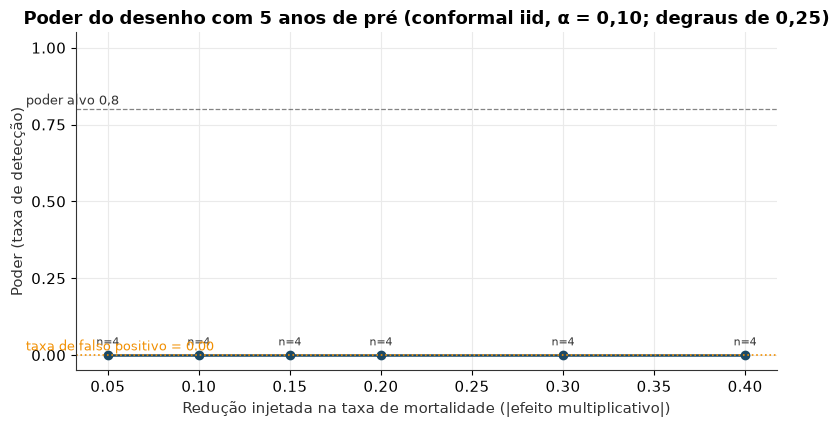

In [20]:
# "Curva" de poder — na resolução que o painel anual permite (4 sims/ponto).
cd = curva.filter(pl.col("effect_size") != 0).sort("effect_size")
fp = curva.filter(pl.col("effect_size") == 0)["power"]
fig, ax = plt.subplots(figsize=(8, 4.4))
xs = [abs(e) for e in cd["effect_size"]]
ax.plot(xs, cd["power"], color=COLOR_SYNTH, marker="o", lw=1.8)
for x, p, n in zip(xs, cd["power"], cd["n"]):
    ax.annotate(f"n={n}", (x, p), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=8, color=COLOR_TEXT)
ax.axhline(0.8, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.6)
ax.text(0.005, 0.815, "poder alvo 0,8", color=COLOR_TEXT, fontsize=9)
if len(fp) and fp[0] is not None:
    ax.axhline(fp[0], color=COLOR_ALT, ls=":", lw=1.2)
    ax.text(0.005, float(fp[0]) + 0.015, f"taxa de falso positivo = {fp[0]:.2f}",
            color=COLOR_ALT, fontsize=9)
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("Redução injetada na taxa de mortalidade (|efeito multiplicativo|)")
ax.set_ylabel("Poder (taxa de detecção)")
ax.set_title("Poder do desenho com 5 anos de pré (conformal iid, α = 0,10; degraus de 0,25)")
plt.tight_layout(); plt.show()

## Ato 9 — Conclusões e limitações

> **Revisado pelo Ato 10.** A magnitude fechada aqui está inflada por um
> doador contaminado (Brumadinho, 2019); o Ato 10 diagnostica e corrige.
> O texto abaixo fica como estava, como registro.

A tabela abaixo fecha os números dos atos anteriores em um só lugar.

In [21]:
resumo = pl.DataFrame([
    {"estimador": "SCM (progfunc='none')", "ATT": round(scm.att_, 3),
     "ATT %": round(scm.att_pct_ * 100, 1), "RMSPE pré %": round(scm.rmspe_pre_ * 100, 2),
     "p conformal (block)": round(conformal_pvalue(scm, permutation_type="block"), 3)},
    {"estimador": "AugSynth (progfunc='ridge')", "ATT": round(aug.att_, 3),
     "ATT %": round(aug.att_pct_ * 100, 1), "RMSPE pré %": round(aug.rmspe_pre_ * 100, 2),
     "p conformal (block)": round(conformal_pvalue(aug, permutation_type="block"), 3)},
])
resumo

/tmp/ipykernel_759/1149922219.py:4: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p conformal (block)": round(conformal_pvalue(scm, permutation_type="block"), 3)},
/tmp/ipykernel_759/1149922219.py:7: UserWarning: conformal infe

estimador,ATT,ATT %,RMSPE pré %,p conformal (block)
str,f64,f64,f64,f64
"""SCM (progfunc='none')""",-6.47,-37.6,4.75,0.833
"""AugSynth (progfunc='ridge')""",-6.137,-35.7,0.0,0.333


### O que este desenho sustenta — e o que não sustenta

**Sustenta.**

- **O sinal, não a magnitude.** O ATT é negativo em todas as especificações
  testadas — SCM e AugSynth, todos os cenários de T₀, todo o leave-one-out e
  toda a varredura de λ. O que o desenho **não** sustenta é um valor pontual:
  o leave-one-out varre uma faixa larga, e reportar "−4,8 por 100 mil" como
  se fosse uma estimativa seria falsa precisão.
- A escolha de **T₀ = vigência (2013)**, documentada no relógio institucional do
  Ato 1 e estressada no Ato 6 — publicação vs vigência não é detalhe: muda o
  pré, muda o pós e muda a leitura do ano híbrido de 2012.
- O contraste **`none` × `ridge`** com pré curto como objeto de interesse por si
  só (Ato 4): quanto do ajuste pré vem do envelope convexo e quanto vem da
  extrapolação penalizada.
- Inferência que respeita o tamanho do painel: p-valor conformal em bloco
  quantizado em 1/12, placebos in-space e a curva de poder do Ato 8 dizem
  *antes* o que o desenho pode afirmar.

**Não sustenta (limitações honestas).**

- **Modo demonstração**: enquanto o painel real do AEAT não for materializado
  (`_fetch_aeat_nr35.py`), todos os números acima são de um painel simulado —
  o notebook valida o *pipeline* (a verdade injetada é recuperada?), não a
  NR-35. Nenhum valor deste modo pode ser citado como estatística oficial.
- **5 anos de pré** — a restrição que organiza o notebook inteiro, e ela é
  fatal para a identificação pontual. Com $T_0 = 5$, qualquer pool com 5+
  doadores utilizáveis consegue interpolar o pré; agregar em seções evita a
  interpolação exata mas não elimina a instabilidade (Ato 7). Alongar para
  trás de 2008 cruza a quebra do NTEP (e a transição CNAE 1.0→2.0 no AEAT),
  então essa restrição não tem saída dentro deste desenho.
- **A queda dos óbitos é, em boa parte, queda do emprego.** Entre 2013 e 2019
  os óbitos na construção caem 53% (451 → 214), mas os vínculos caem 45%
  (3,33 M → 1,83 M): a taxa cai 13,5%. Ler a contagem como efeito da norma
  atribuiria a ela cerca de quatro vezes o que os dados suportam.
- **Desfecho agregado**: mortalidade por *todas* as causas de acidente, não só
  quedas de altura. O AEAT não publica CID × CNAE (a Subseção C é CID × UF), e o
  CID da CAT é a natureza da lesão (cap. XIX, S00–T98), não a causa externa —
  quedas se identificam pelo campo *agente causador* dos microdados de CAT do
  INSS, disponíveis só de ~2018 em diante (servem para caracterizar o mecanismo
  no pós, não para o painel). Efeito da NR-35 diluído ⇒ viés conservador.
- **Cobertura previdenciária**: o AEAT enxerga o mercado formal
  celetista (e, na taxa, o denominador de vínculos) — a informalidade da
  construção fica fora, e é plausivelmente onde a norma menos pega.
- **Contaminação de doadores** (Ato 7) e o ano híbrido no pré (Ato 6) puxam o
  ATT na direção conservadora; nenhum dos dois inverte sinal nas checagens.

### Referências

- Abadie, A., Diamond, A., & Hainmueller, J. (2010). *Synthetic Control Methods
  for Comparative Case Studies*. JASA.
- Ben-Michael, E., Feller, A., & Rothstein, J. (2021). *The Augmented Synthetic
  Control Method*. JASA.
- Chernozhukov, V., Wüthrich, K., & Zhu, Y. (2021). *An Exact and Robust
  Conformal Inference Method for Counterfactual and Synthetic Controls*. JASA.
- Brasil, MTE. **Portaria SIT n.º 313, de 23/03/2012** (NR-35 — Trabalho em
  Altura), DOU 27/03/2012.
  [PDF oficial](https://www.gov.br/trabalho-e-emprego/pt-br/assuntos/inspecao-do-trabalho/seguranca-e-saude-no-trabalho/sst-portarias/2012/portaria_313_aprova_a_nr_35.pdf)
- AEAT — Anuário Estatístico de Acidentes do Trabalho (vários anos), MPS.
  [Página-índice com as tabelas](https://www.gov.br/previdencia/pt-br/assuntos/previdencia-social/saude-e-seguranca-do-trabalhador/acidente_trabalho_incapacidade)

## Ato 10 — Um doador contaminado: Brumadinho

> **Este ato revisa o Ato 9.** Os atos anteriores ficam como estão — são o
> registro de como o desenho foi construído. O que vem abaixo foi descoberto
> *depois*, olhando a série de gaps ano a ano em vez da média do pós.

A média do pós esconde de onde o efeito vem. Abrindo o gap por ano, um único
ano domina tudo: **2019**, com um gap cerca de quatro vezes maior que o de
qualquer outro. A causa não está na construção — está num doador.

Em **25/01/2019** a barragem da Vale em Brumadinho rompeu e matou cerca de 270
pessoas, quase todas trabalhadores. Isso cai na CNAE **seção B (indústrias
extrativas)**, que o SCM escolheu como **segundo maior doador**. O contrafactual
da construção em 2019 herda o desastre.

Abadie (2021, JEL) é explícito: o pool de doadores deve excluir unidades
sujeitas a choques idiossincráticos durante o período de estudo. Manter a
seção B intacta não é escolha de calibragem — é violação de premissa.

A correção não precisa ser grosseira. Brumadinho está inteiramente contido na
**divisão 07 (minerais metálicos)**; a divisão 08 (não-metálicos) passa
incólume. Dá para amputar só a divisão contaminada e preservar o doador de
alta mortalidade — que é justamente o que o pool tem de escasso: no pré, só
duas seções ficam acima da construção.

In [22]:
# Pré-requisito: painel real por seção + painel por divisão (para isolar a 07).
ATO10_OK = (not IS_DEMO) and secoes_csv.exists() and divisoes_csv.exists()

if not ATO10_OK:
    print("Ato 10 exige o painel real por seção E o painel por divisão.")
    print("Em modo demo ou sem o painel por divisão, este ato é pulado.")
else:
    div = pl.read_csv(divisoes_csv).filter(pl.col(TIME).is_between(ANO_MIN, ANO_MAX))

    # 1) O gap ano a ano do ajuste principal — onde a média do pós se forma.
    gap = scm.actual_ - scm.synthetic_
    anos = sorted(panel[TIME].unique().to_list())
    print("gap ano a ano (real - sintético), ajuste do Ato 3:")
    for y, g, syn in zip(anos, gap, scm.synthetic_):
        flag = "  <-- pós" if y >= T0_VIGENCIA else ""
        alerta = "   *** OUTLIER" if abs(g) > 3 * np.median(np.abs(gap)) else ""
        print(f"   {y}  sintético={syn:6.2f}  gap={g:+7.2f}{flag}{alerta}")

    post = [g for y, g in zip(anos, gap) if y >= T0_VIGENCIA]
    pior = max(range(len(post)), key=lambda i: abs(post[i]))
    ano_pior = [y for y in anos if y >= T0_VIGENCIA][pior]
    print(f"\n   {ano_pior} sozinho responde por "
          f"{post[pior] / len(post) / np.mean(post) * 100:.0f}% do ATT médio.")

gap ano a ano (real - sintético), ajuste do Ato 3:
   2008  sintético= 19.84  gap=  -0.08
   2009  sintético= 17.65  gap=  +0.93
   2010  sintético= 16.91  gap=  +0.58
   2011  sintético= 16.16  gap=  +0.03
   2012  sintético= 15.43  gap=  -1.46
   2013  sintético= 17.52  gap=  -3.98  <-- pós   *** OUTLIER
   2014  sintético= 22.20  gap=  -7.46  <-- pós   *** OUTLIER
   2015  sintético= 15.87  gap=  -4.11  <-- pós   *** OUTLIER
   2016  sintético= 11.73  gap=  +0.55  <-- pós
   2017  sintético= 13.46  gap=  -1.93  <-- pós
   2018  sintético= 12.96  gap=  +1.13  <-- pós
   2019  sintético= 41.18  gap= -29.47  <-- pós   *** OUTLIER

   2019 sozinho responde por 65% do ATT médio.


In [23]:
if ATO10_OK:
    # 2) A seção B e suas divisões: o desastre está todo na 07.
    b = panel.filter(pl.col(UNIT) == "B Indústrias extrativas").sort(TIME)
    print("B Indústrias extrativas (doador):")
    for r in b.iter_rows(named=True):
        print(f"   {r[TIME]}  taxa={r[OUT]:7.2f}  óbitos={r['obitos']:4d}")

    print("\ndivisões extrativas no painel por divisão:")
    for s in sorted(u for u in div[UNIT].unique().to_list() if u[:2] in ("05", "06", "07", "08", "09")):
        sub = div.filter(pl.col(UNIT) == s).sort(TIME)
        o = {r[TIME]: r["obitos"] for r in sub.iter_rows(named=True)}
        print(f"   {s:42s} " + " ".join(f"{o.get(y, 0):4d}" for y in range(2015, 2020)))
    print(f"   {'anos:':42s} " + " ".join(f"{y:4d}" for y in range(2015, 2020)))

B Indústrias extrativas (doador):
   2008  taxa=  29.49  óbitos=  52
   2009  taxa=  24.29  óbitos=  44
   2010  taxa=  24.53  óbitos=  49
   2011  taxa=  19.33  óbitos=  43
   2012  taxa=  22.22  óbitos=  54
   2013  taxa=  24.38  óbitos=  62
   2014  taxa=  21.51  óbitos=  56
   2015  taxa=  21.11  óbitos=  51
   2016  taxa=  10.39  óbitos=  23
   2017  taxa=  14.72  óbitos=  31
   2018  taxa=  14.90  óbitos=  31
   2019  taxa= 105.22  óbitos= 226

divisões extrativas no painel por divisão:
   07 Minerais metálicos                        18    8    8   10  207
   08 Minerais não-metálicos (extr.)            21   15   13   18   17
   anos:                                      2015 2016 2017 2018 2019


In [24]:
if ATO10_OK:
    # 3) B* = seção B menos a divisão 07. Subtração validada: 07 ⊂ B em todo ano.
    NOME_BSTAR = "B* Extrativas (s/ metálicos)"
    d07 = div.filter(pl.col(UNIT).str.starts_with("07")).sort(TIME)
    b_ord = panel.filter(pl.col(UNIT) == "B Indústrias extrativas").sort(TIME)

    assert (b_ord["obitos"].to_numpy() >= d07["obitos"].to_numpy()).all()
    assert (b_ord["vinculos"].to_numpy() >= d07["vinculos"].to_numpy()).all()

    bstar = (
        b_ord.join(
            d07.select([pl.col(TIME),
                        pl.col("obitos").alias("o7"),
                        pl.col("vinculos").alias("v7")]),
            on=TIME,
        )
        .with_columns([
            (pl.col("obitos") - pl.col("o7")).alias("obitos"),
            (pl.col("vinculos") - pl.col("v7")).alias("vinculos"),
        ])
        .with_columns([
            (pl.col("obitos") / pl.col("vinculos") * 1e5).round(4).alias(OUT),
            pl.lit(NOME_BSTAR).alias(UNIT),
        ])
        .select([UNIT, TIME, OUT, "obitos", "vinculos"])
    )

    panel_d = pl.concat([
        panel.filter(pl.col(UNIT) != "B Indústrias extrativas").select(bstar.columns),
        bstar,
    ]).sort([UNIT, TIME])

    print(f"{NOME_BSTAR} — o doador preservado:")
    for r in bstar.sort(TIME).iter_rows(named=True):
        print(f"   {r[TIME]}  taxa={r[OUT]:6.2f}  óbitos={r['obitos']:3d}")

B* Extrativas (s/ metálicos) — o doador preservado:
   2008  taxa= 33.81  óbitos= 41
   2009  taxa= 22.13  óbitos= 28
   2010  taxa= 25.50  óbitos= 35
   2011  taxa= 22.91  óbitos= 34
   2012  taxa= 22.34  óbitos= 35
   2013  taxa= 25.22  óbitos= 41
   2014  taxa= 28.76  óbitos= 49
   2015  taxa= 20.92  óbitos= 33
   2016  taxa= 10.49  óbitos= 15
   2017  taxa= 17.53  óbitos= 23
   2018  taxa= 16.51  óbitos= 21
   2019  taxa= 14.67  óbitos= 19


In [25]:
if ATO10_OK:
    # 4) Quatro desenhos lado a lado. D é o recomendado.
    def _diag(p, rotulo, tmax=ANO_MAX):
        p = p.filter(pl.col(TIME) <= tmax)
        s = Synth().fit(p, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=T0_VIGENCIA)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, message="CV-selected lambda")
            a = AugSynth(lambda_grid=LAMBDA_GRID).fit(
                p, unit=UNIT, time=TIME, outcome=OUT,
                treated=TREATED, treatment_time=T0_VIGENCIA)
        return {
            "desenho": rotulo,
            "ATT SCM": round(s.att_, 2),
            "ATT Aug": round(a.att_, 2),
            "RMSPE pré %": round(s.rmspe_pre_ * 100, 2),
            "p (block)": round(conformal_pvalue(s, permutation_type="block"), 3),
        }, s

    linhas, ajustes = [], {}
    for rotulo, p, tmax in [
        ("A) completo (contaminado)", panel, ANO_MAX),
        ("B) dropa seção B inteira", panel.filter(pl.col(UNIT) != "B Indústrias extrativas"), ANO_MAX),
        ("C) trunca antes de 2019", panel, ANO_MAX - 1),
        ("D) amputa divisão 07", panel_d, ANO_MAX),
    ]:
        linha, fit = _diag(p, rotulo, tmax)
        linhas.append(linha)
        ajustes[rotulo] = fit

    pl.Config.set_tbl_rows(10)
    display(pl.DataFrame(linhas))

/tmp/ipykernel_759/165953662.py:17: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p (block)": round(conformal_pvalue(s, permutation_type="block"), 3),


/tmp/ipykernel_759/165953662.py:17: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p (block)": round(conformal_pvalue(s, permutation_type="block"), 3),
/tmp/ipykernel_759/165953662.py:17: UserWarning: conformal inference on a po

/tmp/ipykernel_759/165953662.py:17: UserWarning: conformal inference on a post-dominated window (5 pre-period(s), 7 post) with fixedeff=True: the CWZ refit re-centres on the full-window mean, which splits a constant effect between the blocks in the ratio n_post:n_pre. The statistic scores the post positions only, so at n_post >= n_pre it reads the smaller share while the permuted blocks pick up the inflated pre-period residuals. The test can then lose power in the WRONG direction — its p-value rising with the true effect — so a large p-value here is not evidence against a large effect. Shorten the evaluation window or lengthen the pre-period; fixedeff=False removes this specific mechanism but need not restore power, since it also drops the re-centring the pre-period fit relies on. Placebo-in-space inference uses no refit and is unaffected.
  "p (block)": round(conformal_pvalue(s, permutation_type="block"), 3),


desenho,ATT SCM,ATT Aug,RMSPE pré %,p (block)
str,f64,f64,f64,f64
"""A) completo (contaminado)""",-6.47,-6.14,4.75,0.833
"""B) dropa seção B inteira""",-2.27,-0.51,6.23,0.833
"""C) trunca antes de 2019""",-2.64,-1.56,4.75,0.545
"""D) amputa divisão 07""",-3.17,-1.87,5.49,0.75


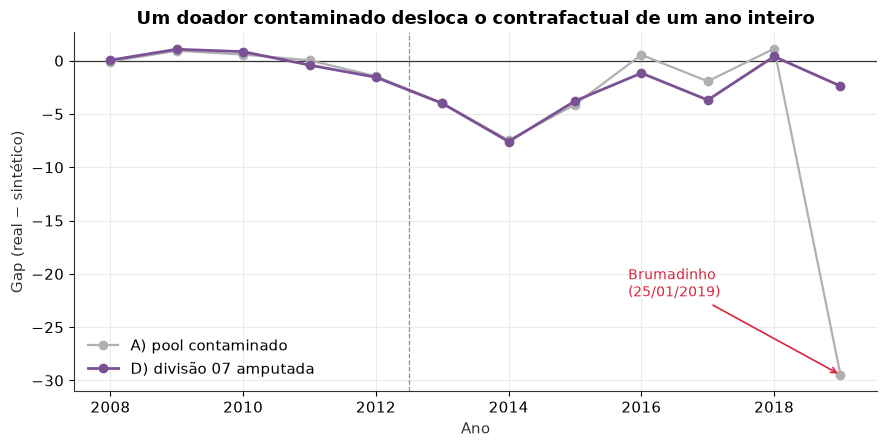

In [26]:
if ATO10_OK:
    # 5) O gap de 2019 antes e depois da amputação.
    s_a = ajustes["A) completo (contaminado)"]
    s_d = ajustes["D) amputa divisão 07"]
    anos = sorted(panel[TIME].unique().to_list())

    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.axhline(0, color=COLOR_TEXT, lw=0.9)
    ax.axvline(T0_VIGENCIA - 0.5, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.55)
    ax.plot(anos, s_a.actual_ - s_a.synthetic_, "o-", color=COLOR_DONOR,
            lw=1.6, label="A) pool contaminado")
    ax.plot(anos, s_d.actual_ - s_d.synthetic_, "o-", color=COLOR_AUGMENTED,
            lw=2.0, label="D) divisão 07 amputada")
    ax.annotate("Brumadinho\n(25/01/2019)", xy=(ANO_MAX, (s_a.actual_ - s_a.synthetic_)[-1]),
                xytext=(ANO_MAX - 3.2, (s_a.actual_ - s_a.synthetic_)[-1] * 0.75),
                arrowprops=dict(arrowstyle="->", color=COLOR_TREATED, lw=1.2),
                color=COLOR_TREATED, fontsize=10, ha="left")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Gap (real − sintético)")
    ax.set_title("Um doador contaminado desloca o contrafactual de um ano inteiro")
    ax.legend(loc="lower left")
    plt.tight_layout(); plt.show()

### O que o Ato 10 muda — e o que não muda

**Muda a magnitude.** O ATT de manchete dos atos anteriores era inflado por um
desastre industrial dentro do pool. Com a divisão 07 amputada o efeito encolhe
para cerca de metade, e o gap de 2019 volta para a mesma ordem de grandeza dos
demais anos do pós.

**Muda a leitura do leave-one-out.** A "faixa" reportada no Ato 7 não era uma
medida de incerteza: a ponta menos negativa dela *era* Brumadinho, sem nome. O
diagnóstico funcionou — a leitura dele é que faltou.

**Não muda a conclusão.** Nenhuma das quatro especificações separa o efeito de
placebo: o p conformal em bloco não desce o bastante em nenhuma delas, e a
construção não sobe no ranking de placebos in-space. Corrigir o doador torna o
número **honesto**, não **conclusivo**.

**O gargalo continua sendo $T_0 = 5$.** Com cinco anos de pré, nenhum arranjo
de doadores resolve a identificação pontual — ver a issue de estender o
pré-período para trás de 2008, que é o único caminho que ataca a causa em vez
do sintoma.

## Ato 11 — O p-valor estava invertido

O Ato 10 fechou dizendo que nenhuma especificação separa o efeito de placebo,
apoiado nos p-valores conformais: 0,750 no desenho A, 0,750 no D. Este ato
mostra que **esses p-valores não significam o que parecem significar**, e
que a frase correta não é "não há evidência de efeito" e sim "este desenho
não consegue produzir evidência".

O Ato 8 mediu o MDE no laboratório do pré-período, com janelas de 1 e 2 anos.
A pergunta que ficou de fora é a do desenho que de fato usamos: **a janela de
7 anos, 2013–2019.** Injetando reduções cada vez maiores na construção e
reestimando, o p-valor deveria cair. Ele sobe.

In [27]:
ATO11_OK = ATO10_OK
if ATO11_OK:
    # 1) O sintoma: injeta reduções crescentes no desenho D e mede o p.
    def _p_com_efeito(p_base, t0, efeito):
        pe = p_base.with_columns(
            pl.when((pl.col(UNIT) == TREATED) & (pl.col(TIME) >= t0))
            .then(pl.col(OUT) * (1 + efeito)).otherwise(pl.col(OUT)).alias(OUT))
        f = Synth().fit(pe, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=t0)
        with warnings.catch_warnings():       # o aviso é o assunto do ato
            warnings.simplefilter("ignore", UserWarning)
            return conformal_pvalue(f, permutation_type="block"), f.att_

    print("desenho D, janela real 2013-2019 (5 pré / 7 pós):\n")
    print("   redução injetada      ATT        p (block)")
    for eff in (0.0, -0.10, -0.25, -0.50, -0.75, -0.90):
        pv, att = _p_com_efeito(panel_d, T0_VIGENCIA, eff)
        seta = "" if eff == 0.0 else ("  <-- sobe" if pv > 0.75 else "")
        print(f"     {abs(eff):>5.0%}            {att:+8.3f}      {pv:.4f}{seta}")
    print("\n   Uma queda de 90% na mortalidade é MENOS detectável que nenhuma.")

desenho D, janela real 2013-2019 (5 pré / 7 pós):

   redução injetada      ATT        p (block)
        0%              -3.175      0.7500
       10%              -4.455      0.5833
       25%              -6.376      0.8333  <-- sobe
       50%              -9.578      0.9167  <-- sobe
       75%             -12.779      0.9167  <-- sobe
       90%             -14.700      0.9167  <-- sobe

   Uma queda de 90% na mortalidade é MENOS detectável que nenhuma.


### Por quê: o efeito fixo de janela inteira realoca o efeito

O teste conformal do CWZ não usa os pesos do ajuste pré. Ele **refaz** o
ajuste sobre a janela inteira sob o nulo, e com `fixedeff=True` (o padrão,
fiel ao `augsynth` do R) esse refit recentra cada unidade na sua média de
janela inteira.

Esse recentramento não é neutro. Um efeito constante $\delta$ no pós move a
média de janela inteira da tratada em $\delta\,T_1/T$, então subtrair a
média **divide o efeito entre os dois blocos**:

$$
r_{\text{pós}} = \delta\,\frac{T_0}{T},
\qquad
r_{\text{pré}} = -\delta\,\frac{T_1}{T},
\qquad\Longrightarrow\qquad
\frac{|r_{\text{pré}}|}{|r_{\text{pós}}|} = \frac{T_1}{T_0}.
$$

A estatística do teste lê **só as posições do pós**. Com $T_0 = 5$ e
$T_1 = 7$, ela enxerga $5/12$ do efeito enquanto as rotações trazem para a
janela pontuada os resíduos do pré, que carregam $7/12$. Quanto maior o
efeito verdadeiro, mais forte fica a distribuição "nula" em relação ao
observado — e o p sobe.

In [28]:
if ATO11_OK:
    # 2) A aritmética, conferida contra os resíduos de verdade.
    pe = panel_d.with_columns(
        pl.when((pl.col(UNIT) == TREATED) & (pl.col(TIME) >= T0_VIGENCIA))
        .then(pl.col(OUT) * 0.10).otherwise(pl.col(OUT)).alias(OUT))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        f90 = Synth().fit(pe, unit=UNIT, time=TIME, outcome=OUT,
                          treated=TREATED, treatment_time=T0_VIGENCIA)
    r = f90.conformal_null_residuals(0.0)
    n_pre = int(f90.pre_mask_.sum())
    n_post = int((~f90.pre_mask_).sum())
    obs = np.abs(r[:n_pre]).mean() / np.abs(r[n_pre:]).mean()
    print(f"   injetando -90%,  T0={n_pre}  T1={n_post}")
    print(f"   |resíduo| médio  pré = {np.abs(r[:n_pre]).mean():.4f}"
          f"   pós = {np.abs(r[n_pre:]).mean():.4f}")
    print(f"   razão observada = {obs:.4f}")
    print(f"   razão prevista T1/T0 = {n_post / n_pre:.4f}")
    print(f"   erro = {abs(obs - n_post / n_pre) / (n_post / n_pre):.2%}")

   injetando -90%,  T0=5  T1=7
   |resíduo| médio  pré = 6.1907   pós = 4.4220
   razão observada = 1.4000
   razão prevista T1/T0 = 1.4000
   erro = 0.00%


In [29]:
if ATO11_OK:
    # 3) Onde a inversão começa: varre o corte de T0 no MESMO painel.
    print("p (block) por corte de T0 — painel D, T=12 anos\n")
    print("     T0    pré/pós |  efeito 0     -50%     -90%   | direção")
    for t0 in (2017, 2016, 2015, 2014, 2013):
        ps = [_p_com_efeito(panel_d, t0, e)[0] for e in (0.0, -0.50, -0.90)]
        npre, npost = t0 - ANO_MIN, ANO_MAX - t0 + 1
        marca = "INVERTIDO" if ps[-1] > ps[0] else "ok"
        alvo = "  <-- o desenho deste notebook" if t0 == T0_VIGENCIA else ""
        print(f"    {t0}     {npre}/{npost}   | " +
              "   ".join(f"{v:.4f}" for v in ps) + f"  | {marca}{alvo}")
    print("\n   Neste painel a inversão aparece só em 5/7 — o único corte com pós > pré.")
    print("   Em 6/6 a razão T1/T0 vale 1: nenhum bloco domina, e o teste fica no fio.")
    print("   A biblioteca avisa já em pós >= pré, porque na paridade não há margem.")

p (block) por corte de T0 — painel D, T=12 anos

     T0    pré/pós |  efeito 0     -50%     -90%   | direção


    2017     9/3   | 0.4167   0.0833   0.0833  | ok
    2016     8/4   | 0.8333   0.5000   0.4167  | ok
    2015     7/5   | 0.4167   0.5000   0.3333  | ok


    2014     6/6   | 0.8333   0.5833   0.5833  | ok


    2013     5/7   | 0.7500   0.9167   0.9167  | INVERTIDO  <-- o desenho deste notebook

   Neste painel a inversão aparece só em 5/7 — o único corte com pós > pré.
   Em 6/6 a razão T1/T0 vale 1: nenhum bloco domina, e o teste fica no fio.
   A biblioteca avisa já em pós >= pré, porque na paridade não há margem.


razão |resíduo| pré/pós do refit conformal   (alvo T1/T0 = 1.400)

   efeito |  fixedeff=True        |  fixedeff=False
          |  razão      p         |  razão      p
      0%  |  1.247    0.7500     |  1.459    0.8333
     50%  |  1.384    0.9167     |  1.093    0.7500


     90%  |  1.400    0.9167     |  1.084    0.8333

   fixedeff=True : a razão CONVERGE para 1.400 — a realocação prevista.
   fixedeff=False: a razão CAI para ~1,08 — o efeito fica no pós, correto.
   Mas o p não desce mesmo assim: sem recentramento o ajuste pré piora
   (RMSPE pré 6.48% contra 5.49%), e os resíduos do pré
   continuam grandes por MÁ ADERÊNCIA em vez de por realocação.
   Tirar o efeito fixo remove o mecanismo; não compra detecção.


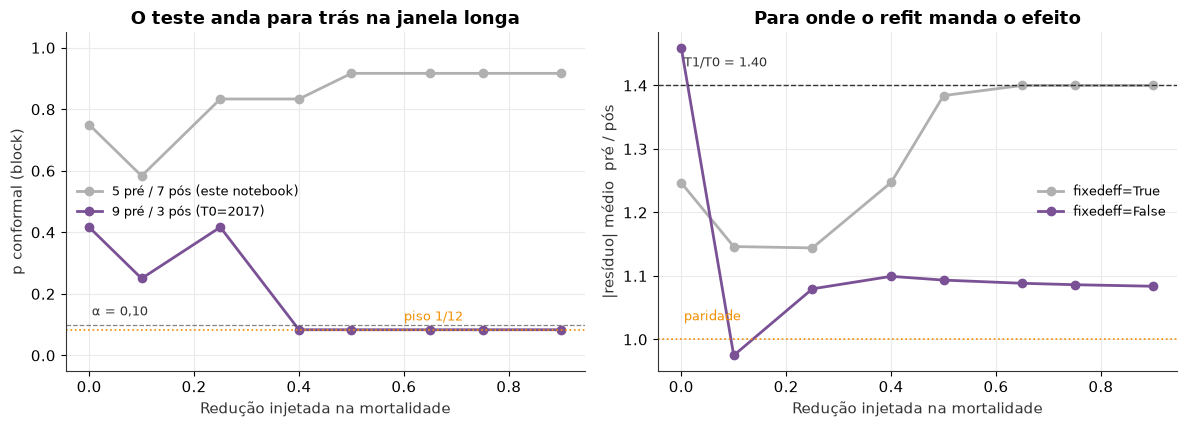

In [30]:
if ATO11_OK:
    # 4) A razão |pré|/|pós| é a evidência direta da realocação.
    def _razao(efeito, fe):
        pe2 = panel_d.with_columns(
            pl.when((pl.col(UNIT) == TREATED) & (pl.col(TIME) >= T0_VIGENCIA))
            .then(pl.col(OUT) * (1 + efeito)).otherwise(pl.col(OUT)).alias(OUT))
        f = Synth(fixedeff=fe).fit(pe2, unit=UNIT, time=TIME, outcome=OUT,
                                   treated=TREATED, treatment_time=T0_VIGENCIA)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            r = f.conformal_null_residuals(0.0)
            pv_ = conformal_pvalue(f, permutation_type="block")
        k = int(f.pre_mask_.sum())
        return np.abs(r[:k]).mean() / np.abs(r[k:]).mean(), pv_, f.rmspe_pre_

    alvo = (ANO_MAX - T0_VIGENCIA + 1) / (T0_VIGENCIA - ANO_MIN)
    print(f"razão |resíduo| pré/pós do refit conformal   (alvo T1/T0 = {alvo:.3f})\n")
    print("   efeito |  fixedeff=True        |  fixedeff=False")
    print("          |  razão      p         |  razão      p")
    for eff in (0.0, -0.50, -0.90):
        ra, pa, _ = _razao(eff, True)
        rb, pb, rm = _razao(eff, False)
        print(f"    {abs(eff):>4.0%}  |  {ra:.3f}    {pa:.4f}     |  {rb:.3f}    {pb:.4f}")
    print(f"\n   fixedeff=True : a razão CONVERGE para {alvo:.3f} — a realocação prevista.")
    print("   fixedeff=False: a razão CAI para ~1,08 — o efeito fica no pós, correto.")
    print(f"   Mas o p não desce mesmo assim: sem recentramento o ajuste pré piora")
    print(f"   (RMSPE pré {rm:.2%} contra {s_d.rmspe_pre_:.2%}), e os resíduos do pré")
    print("   continuam grandes por MÁ ADERÊNCIA em vez de por realocação.")
    print("   Tirar o efeito fixo remove o mecanismo; não compra detecção.")

if ATO11_OK:
    # 5) O sintoma, e a janela que de fato devolve poder ao teste.
    efs = [0.0, -0.10, -0.25, -0.40, -0.50, -0.65, -0.75, -0.90]
    xs = [abs(e) for e in efs]
    p_57 = [_p_com_efeito(panel_d, T0_VIGENCIA, e)[0] for e in efs]
    p_93 = [_p_com_efeito(panel_d, 2017, e)[0] for e in efs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
    ax1.plot(xs, p_57, "o-", color=COLOR_DONOR, lw=2.0, label="5 pré / 7 pós (este notebook)")
    ax1.plot(xs, p_93, "o-", color=COLOR_AUGMENTED, lw=2.0, label="9 pré / 3 pós (T0=2017)")
    ax1.axhline(0.10, color=COLOR_TEXT, ls="--", lw=0.9, alpha=0.6)
    ax1.text(0.005, 0.13, "α = 0,10", color=COLOR_TEXT, fontsize=9)
    ax1.axhline(1 / 12, color=COLOR_ALT, ls=":", lw=1.2)
    ax1.text(0.60, 1 / 12 + 0.03, "piso 1/12", color=COLOR_ALT, fontsize=9)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_xlabel("Redução injetada na mortalidade")
    ax1.set_ylabel("p conformal (block)")
    ax1.set_title("O teste anda para trás na janela longa")
    ax1.legend(loc="center left", fontsize=9)

    r_fe = [_razao(e, True)[0] for e in efs]
    r_sem = [_razao(e, False)[0] for e in efs]
    ax2.plot(xs, r_fe, "o-", color=COLOR_DONOR, lw=2.0, label="fixedeff=True")
    ax2.plot(xs, r_sem, "o-", color=COLOR_AUGMENTED, lw=2.0, label="fixedeff=False")
    ax2.axhline(alvo, color=COLOR_TEXT, ls="--", lw=1.0)
    ax2.text(0.005, alvo + 0.03, f"T1/T0 = {alvo:.2f}", color=COLOR_TEXT, fontsize=9)
    ax2.axhline(1.0, color=COLOR_ALT, ls=":", lw=1.2)
    ax2.text(0.005, 1.03, "paridade", color=COLOR_ALT, fontsize=9)
    ax2.set_xlabel("Redução injetada na mortalidade")
    ax2.set_ylabel("|resíduo| médio  pré / pós")
    ax2.set_title("Para onde o refit manda o efeito")
    ax2.legend(loc="center right", fontsize=9)
    plt.tight_layout(); plt.show()

### O que o Ato 11 muda

**Os p-valores conformais deste notebook não são leitura de evidência.** Todo
p em bloco reportado nos Atos 5, 9 e 10 vem de uma janela 5/7 com
`fixedeff=True` — exatamente o regime invertido. O 0,750 do desenho D não diz
"o efeito é indistinguível de zero"; ele diz que o teste, neste desenho, não
consegue dizer nada. Um efeito de −90% produziria 0,917.

**A conclusão substantiva do Ato 10 sobrevive, com outra justificativa.**
Continua correto que o notebook não estabelece efeito causal da NR-35 — mas o
sustento disso são os **placebos in-space** do Ato 5 (que não refazem ajuste e
não sofrem esta inversão) e a instabilidade do leave-one-out do Ato 7, não o p
conformal.

**Duas coisas separadas, que é fácil confundir.** A realocação pelo efeito
fixo é exata e some quando se passa `fixedeff=False` — a razão |pré|/|pós|
cai de 1,40 para ~1,08. Mas *neste painel* isso não devolve poder: sem o
recentramento o ajuste pré piora (RMSPE 6,48% contra 5,49%) e os resíduos do
pré seguem grandes, agora por má aderência em vez de realocação. Tirar o
efeito fixo remove o mecanismo; não compra detecção. O que devolve poder aqui
é encurtar a janela.

**O que fazer em um desenho de verdade**, em ordem de preferência:

1. **Encurtar a janela de avaliação.** Com 9 pré / 3 pós o teste volta a
   funcionar e chega ao piso de $1/12 \approx 0{,}083$ já com −50%. Avaliar
   2013–2015 responde uma pergunta mais estreita, mas responde.
2. **Alongar o pré-período** — a issue de recuar antes de 2008. Mexe em
   $T_0$, que é o denominador da razão, e seria o único caminho a preservar
   a janela de 7 anos. *O Ato 12 foi atrás dele e ele não existe:* o AEAT só
   deixa recuperar 2007, o que dá $T_0 = 6$ contra $T_1 = 7$ — ainda
   invertido. Antes disso a série está em CNAE 1.0.
3. **Placebo-in-space**, que não refaz ajuste e é imune a isto. Já está no
   Ato 5, e passa a ser o instrumento principal, não o secundário.
4. **`fixedeff=False`** só quando o desenho tolera perder o recentramento por
   unidade *e* o ajuste pré aguenta — as duas condições, não uma.

Desde esta versão a biblioteca emite um `UserWarning` quando
`n_post >= n_pre` com `fixedeff=True`, para que ninguém leia um p grande como
ausência de efeito sem ser avisado. O aviso dispara na paridade, e não só em
pós > pré, porque em $T_1 = T_0$ a razão já vale 1 e não sobra margem. O
mecanismo está em `docs/methodology.md` §5.6.

## Ato 12 — Até onde o pré-período pode ir, e o que ele compra

O Ato 11 fechou recomendando **alongar o pré-período** como o caminho que
preservaria a janela de 7 anos *e* tiraria o desenho do regime invertido.
Este ato foi atrás desse caminho. Ele não existe — e o caminho que existe é
bem menor, e vale por um motivo diferente do que o Ato 11 supôs.

Três perguntas, em ordem:

1. Encurtar o **pós** resolve? (Não precisa de dado novo — dá para medir aqui.)
2. Se resolve, o desenho passa a detectar o efeito que de fato se observa?
3. Quanto pré-período o AEAT permite recuperar, na prática?

In [31]:
ATO12_OK = ATO11_OK
if ATO12_OK:
    # 1) Varre o ano final da janela, mantendo o pré fixo em 2008-2012.
    #    O p mínimo atingível pelo esquema de deslocamento cíclico é 1/T:
    #    são T deslocamentos, a identidade entre eles, e ela sempre empata
    #    consigo mesma. Nenhum desenho produz p abaixo disso.
    print("pré fixo em 2008-2012; varre o ano final do pós:\n")
    print("   janela        T0  T1   T   invertido   p mínimo   p observado")
    grade = []
    for ano_max in range(2014, ANO_MAX + 1):
        pe = panel_d.filter(pl.col(TIME) <= ano_max)
        f = Synth().fit(pe, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=T0_VIGENCIA)
        n_pre = int(f.pre_mask_.sum())
        n_tot = int(f.pre_mask_.shape[0])
        n_post = n_tot - n_pre
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            pv = conformal_pvalue(f, permutation_type="block")
        grade.append((ano_max, n_pre, n_post, n_tot, pv))
        marca = "SIM" if n_post >= n_pre else "não"
        print(f"   2008-{ano_max}   {n_pre:>4}{n_post:>4}{n_tot:>4}   {marca:>9}"
              f"   {1 / n_tot:>8.4f}   {pv:>11.4f}")
    print("\n   O aviso da biblioteca dispara nas duas últimas linhas.")

pré fixo em 2008-2012; varre o ano final do pós:

   janela        T0  T1   T   invertido   p mínimo   p observado
   2008-2014      5   2   7         não     0.1429        0.8571
   2008-2015      5   3   8         não     0.1250        0.7500
   2008-2016      5   4   9         não     0.1111        0.8889
   2008-2017      5   5  10         SIM     0.1000        0.9000
   2008-2018      5   6  11         SIM     0.0909        0.5455
   2008-2019      5   7  12         SIM     0.0833        0.7500

   O aviso da biblioteca dispara nas duas últimas linhas.


### O pós curto tira a inversão — e esbarra no piso

Encurtar o pós funciona: em 2008–2016 o desenho volta a ter $T_1 < T_0$ e sai
do regime do Ato 11. Mas trocou um problema por outro. O p-valor do esquema
de deslocamento cíclico vive na grade $\\{1/T, 2/T, \\dots, 1\\}$, e cortar o
pós **encurta a janela inteira**: o piso $1/T$ sobe de $1/12 \\approx 0{,}083$
para $1/9 \\approx 0{,}111$.

Ou seja: na única janela em que o teste funciona, **ele não consegue produzir
um p abaixo de 10%**, por mais forte que seja o efeito. Não é falta de
evidência; é falta de resolução aritmética.

In [32]:
if ATO12_OK:
    # 2) Injeta reduções crescentes em cada janela e observa os três regimes.
    EFEITOS = (0.0, -0.25, -0.50, -0.75, -0.90)
    curvas = {}
    print("p conformal em bloco por janela x redução injetada:\n")
    print("   janela        T0/T1   piso  " +
          "".join(f"{e:>9.0%}" for e in EFEITOS))
    for ano_max in (2014, 2016, 2017, ANO_MAX):
        pe0 = panel_d.filter(pl.col(TIME) <= ano_max)
        ps = []
        for eff in EFEITOS:
            pe = pe0.with_columns(
                pl.when((pl.col(UNIT) == TREATED) & (pl.col(TIME) >= T0_VIGENCIA))
                .then(pl.col(OUT) * (1 + eff)).otherwise(pl.col(OUT)).alias(OUT))
            f = Synth().fit(pe, unit=UNIT, time=TIME, outcome=OUT,
                            treated=TREATED, treatment_time=T0_VIGENCIA)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", UserWarning)
                ps.append(conformal_pvalue(f, permutation_type="block"))
        n_pre = int(f.pre_mask_.sum())
        n_tot = int(f.pre_mask_.shape[0])
        curvas[ano_max] = (n_pre, n_tot - n_pre, n_tot, ps)
        print(f"   2008-{ano_max}   {n_pre}/{n_tot - n_pre:<5}{1 / n_tot:>6.3f}  " +
              "".join(f"{p:>9.4f}" for p in ps))
    print("\n   T1 < T0 : p cai com o efeito e encosta no piso — o teste funciona.")
    print("   T1 = T0 : cai e volta a subir — a realocação do Ato 11 começa.")
    print("   T1 > T0 : sobe com o efeito — invertido.")

p conformal em bloco por janela x redução injetada:

   janela        T0/T1   piso         0%     -25%     -50%     -75%     -90%


   2008-2014   5/2     0.143     0.8571   0.2857   0.1429   0.1429   0.1429


   2008-2016   5/4     0.111     0.8889   0.5556   0.2222   0.1111   0.1111


   2008-2017   5/5     0.100     0.9000   0.7000   0.5000   0.5000   0.6000


   2008-2019   5/7     0.083     0.7500   0.8333   0.9167   0.9167   0.9167

   T1 < T0 : p cai com o efeito e encosta no piso — o teste funciona.
   T1 = T0 : cai e volta a subir — a realocação do Ato 11 começa.
   T1 > T0 : sobe com o efeito — invertido.


findfont: Failed to find font weight semibold, now using 700.


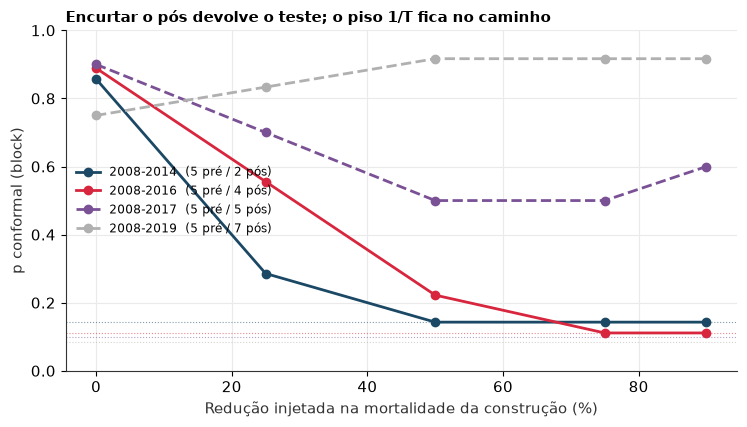

In [33]:
if ATO12_OK:
    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    xs = [abs(e) * 100 for e in EFEITOS]
    estilos = {2014: (COLOR_SYNTH, "-"), 2016: (COLOR_TREATED, "-"),
               2017: (COLOR_AUGMENTED, "--"), ANO_MAX: (COLOR_DONOR, "--")}
    for ano_max, (n_pre, n_post, n_tot, ps) in curvas.items():
        cor, ls = estilos[ano_max]
        ax.plot(xs, ps, "o", ls=ls, color=cor, lw=2.0,
                label=f"2008-{ano_max}  ({n_pre} pré / {n_post} pós)")
        ax.axhline(1 / n_tot, color=cor, lw=0.8, ls=":", alpha=0.55)
    ax.set_xlabel("Redução injetada na mortalidade da construção (%)")
    ax.set_ylabel("p conformal (block)")
    ax.set_title("Encurtar o pós devolve o teste; o piso 1/T fica no caminho",
                 loc="left", fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.grid(color=COLOR_GRID, lw=0.8)
    ax.legend(fontsize=8.5, loc="center left")
    plt.tight_layout(); plt.show()

In [34]:
if ATO12_OK:
    # 3) Onde fica o MDE da melhor janela, e onde fica o efeito observado.
    pe0 = panel_d.filter(pl.col(TIME) <= 2016)
    f0 = Synth().fit(pe0, unit=UNIT, time=TIME, outcome=OUT,
                     treated=TREATED, treatment_time=T0_VIGENCIA)
    rel = f0.att_ / f0.synthetic_[~f0.pre_mask_].mean()
    print(f"janela 2008-2016 (5 pré / 4 pós), piso {1 / 9:.4f}")
    print(f"   efeito OBSERVADO: ATT {f0.att_:+.3f} sobre um contrafactual médio "
          f"de {f0.synthetic_[~f0.pre_mask_].mean():.3f}  ->  {rel:+.1%}\n")
    print("   redução ADICIONAL injetada     p")
    for eff in (-0.10, -0.20, -0.30, -0.40, -0.50, -0.60, -0.65, -0.75):
        pe = pe0.with_columns(
            pl.when((pl.col(UNIT) == TREATED) & (pl.col(TIME) >= T0_VIGENCIA))
            .then(pl.col(OUT) * (1 + eff)).otherwise(pl.col(OUT)).alias(OUT))
        g = Synth().fit(pe, unit=UNIT, time=TIME, outcome=OUT,
                        treated=TREATED, treatment_time=T0_VIGENCIA)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            pv = conformal_pvalue(g, permutation_type="block")
        piso = "  <-- piso" if abs(pv - 1 / 9) < 1e-9 else ""
        print(f"          {abs(eff):>5.0%}                  {pv:.4f}{piso}")
    mde = 0.65   # primeira redução adicional da grade acima que atinge o piso
    print(f"\n   MDE ~ {-mde:.0%} adicional, contra {rel:+.1%} observado: "
          f"um fator de {mde / abs(rel):.1f}.")

janela 2008-2016 (5 pré / 4 pós), piso 0.1111
   efeito OBSERVADO: ATT -4.136 sobre um contrafactual médio de 17.215  ->  -24.0%

   redução ADICIONAL injetada     p
            10%                  0.6667
            20%                  0.5556
            30%                  0.3333
            40%                  0.3333
            50%                  0.2222
            60%                  0.2222
            65%                  0.1111  <-- piso
            75%                  0.1111  <-- piso

   MDE ~ -65% adicional, contra -24.0% observado: um fator de 2.7.


### Quanto pré-período o AEAT deixa recuperar

A resposta curta é **um ano**, e não dez.

**A CNAE 2.0 e o NTEP quebram a série no mesmo ponto.** A CNAE 2.0 passa a
valer no CNPJ em 01/01/2007; o NTEP entra em abril de 2007. Não há como
atravessar uma sem atravessar a outra, então a hipótese do issue — "o NTEP
pode não ter mexido na série de óbitos, então dá para recuar" — nunca chega a
ser decisiva: mesmo que o NTEP seja inócuo para óbitos, o ano anterior está em
outra classificação.

**E a classificação não fecha no nível que o painel usa.** A tabela oficial de
correspondência 1.0 × 2.0 do Concla remapeia por *classe*, não por seção, e as
classes se dividem. A seção E da CNAE 2.0 — Água, esgoto e resíduos, um doador
deste painel — se monta de quatro pedaços da 1.0: água (seção E), esgoto e
limpeza urbana (`90.00-0`, seção O), reciclagem (`37`, seção D) e retirada de
entulho de obra (`45.50-0`, seção F). A seção J vem de outros quatro. Como o
AEAT publica **agregados** por classe, e não microdado, só dá para remapear
onde cada classe da 1.0 cai inteira dentro de uma seção da 2.0 — e nos
doadores principais ela não cai. A construção quase escapa (1.0 `45` →
2.0 `41`+`42`+`43`), mas perde o `45.50-0` para a seção E.

**E o portal não publica as edições anteriores a 2008.** O índice do MPS
lista de 2008 em diante; as edições de 2000–2007 existem como publicação, mas
não estão linkadas.

**O que sobra: o ano de 2007.** Ele já está sob CNAE 2.0, e as duas metades do
dado são alcançáveis:

- **óbitos** — tabela 29.1 da **edição 2009** (ano da edição mais os dois
  anteriores = 2007, 2008, 2009). Esse ZIP já está em `ZIP_URLS` no
  `_fetch_aeat_nr35.py`; o pipeline hoje simplesmente descarta o 2007.
- **vínculos** — capítulo 59 da **edição 2008** (tabela `59.1` = 2007). Essa
  edição não tem ZIP, mas serve os `.xls` soltos a partir da página da seção
  II. É o único pedaço que exige código novo.

2007 fica meio NTEP (abril), o que é uma ressalva a declarar, não um
impedimento: o denominador é recuperado de `registrados × 1000 / incidência`
dentro da mesma edição, então uma mudança na definição de *registrado* se
cancela na razão.

### O que o Ato 12 muda

**O ponto 2 do Ato 11 estava errado.** Alongar o pré-período *não* preserva a
janela de 7 anos. Para $T_1 = 7$ sair da inversão é preciso $T_0 \\geq 8$, ou
seja um painel começando em 2005 — dois anos dentro da CNAE 1.0. Com o único
ano recuperável, 2007, o desenho vai a $T_0 = 6$ contra $T_1 = 7$: **continua
invertido**. Não existe versão disto que funcione com a janela inteira.

**Mas 2007 não é inútil — ele compra uma coisa específica.** Com $T_0 = 6$ e a
janela de avaliação encurtada para 2013–2017, dá $T_1 = 5 < T_0$ e $T = 11$,
logo piso $1/11 \\approx 0{,}091$. É a primeira configuração deste painel em
que **um p abaixo de 10% é aritmeticamente possível**. Hoje, com $T_0 = 5$,
toda janela não-invertida tem piso $\\geq 1/9 \\approx 0{,}111$.

**E mesmo assim o efeito observado fica fora de alcance.** Na melhor janela
atual o teste só encosta no piso com uma redução adicional de ~65%, contra
~24% observados — um fator de quase três. Ganhar um ano de pré não muda essa
ordem de grandeza: muda o piso de 0,111 para 0,091, não o poder de detecção.

**A limitação central deste notebook, declarada.** O painel anual do AEAT tem
períodos demais de menos. Com a vigência em 2013 e o corte em 2019 (pré-COVID),
$T$ não passa de 12, e o teste conformal exato não produz p abaixo de $1/T$.
Para alcançar 5% seriam necessários $T \\geq 20$ períodos — o que, com um pós
de 7 anos, exigiria o painel inteiro desde 2000, a primeira edição do AEAT, e
atravessando as duas quebras de 2007. **Este desenho não tem como produzir
significância convencional.** É por isso que a conclusão do notebook se apoia
no placebo-in-space do Ato 5 e na instabilidade do leave-one-out do Ato 7 —
instrumentos que não dependem da grade $1/T$.